## 0. Environment Setup

In [1]:
# Setup and imports
import sys
import json
import sqlite3
from pathlib import Path
from pprint import pprint
import glob

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /home/feiy/Role-SQL-benchmark


In [2]:
# Load environment and initialize Oracle
from dotenv import load_dotenv
import os

load_dotenv(project_root / '.env')

# Check available API keys
api_keys = {
    'OPENAI_API_KEY': bool(os.getenv('OPENAI_API_KEY')),
    'DEEPSEEK_API_KEY': bool(os.getenv('DEEPSEEK_API_KEY')),
    'DEEPINFRA_API_KEY': bool(os.getenv('DEEPINFRA_API_KEY')),
}
print("Available API keys:")
for k, v in api_keys.items():
    print(f"  {k}: {'✓' if v else '✗'}")

Available API keys:
  OPENAI_API_KEY: ✓
  DEEPSEEK_API_KEY: ✓
  DEEPINFRA_API_KEY: ✓


In [3]:
# Initialize LLM Oracle
from src.llm_oracle import Oracle

# Choose model based on available keys
if os.getenv('DEEPSEEK_API_KEY'):
    MODEL = "deepseek-chat"
    API_KEY = os.getenv('DEEPSEEK_API_KEY')
elif os.getenv('OPENAI_API_KEY'):
    MODEL = "gpt-4o-mini"
    API_KEY = os.getenv('OPENAI_API_KEY')
else:
    raise ValueError("No API key available!")

oracle = Oracle(model=MODEL, apikey=API_KEY)
print(f"Using model: {MODEL}")

Using model: deepseek-chat


/home/feiy/anaconda3/envs/llm4db/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Database Validation and Schema Inspection

Spider databases may not all have `schema.sql` files. We need to validate and filter.

In [4]:
# Define paths
SPIDER_ROOT = project_root / 'data' / 'spider'
SPIDER_DB_DIR = SPIDER_ROOT / 'database'
SPIDER_TEST_DB_DIR = SPIDER_ROOT / 'test_database'
SPIDER_DEV_DATA = SPIDER_ROOT / 'dev.json'
SPIDER_TEST_DATA = SPIDER_ROOT / 'test.json'

print(f"Spider root: {SPIDER_ROOT}")
print(f"Database dir: {SPIDER_DB_DIR}")
print(f"Test database dir: {SPIDER_TEST_DB_DIR}")
print(f"\nPaths exist:")
print(f"  Spider root: {SPIDER_ROOT.exists()}")
print(f"  Database dir: {SPIDER_DB_DIR.exists()}")
print(f"  Dev data: {SPIDER_DEV_DATA.exists()}")
print(f"  Test data: {SPIDER_TEST_DATA.exists()}")

Spider root: /home/feiy/Role-SQL-benchmark/data/spider
Database dir: /home/feiy/Role-SQL-benchmark/data/spider/database
Test database dir: /home/feiy/Role-SQL-benchmark/data/spider/test_database

Paths exist:
  Spider root: True
  Database dir: True
  Dev data: True
  Test data: True


In [5]:
# Utility functions for database validation and policy analysis
# Import shared policy utility functions
from src.role_evaluator.quality_metrics import RoleQualityEvaluator

# Convenience aliases for the static methods
count_policy_columns = RoleQualityEvaluator.count_policy_columns
has_wildcard_policy = RoleQualityEvaluator.has_wildcard_policy

def validate_spider_databases(db_root: Path) -> dict:
    """Validate all databases in a directory."""
    results = {
        'valid': [],
        'missing_schema': [],
        'missing_sqlite': [],
        'total': 0
    }
    
    for db_dir in sorted(db_root.iterdir()):
        if not db_dir.is_dir() or db_dir.name.startswith('.'):
            continue
        
        results['total'] += 1
        db_name = db_dir.name
        
        has_schema = (db_dir / 'schema.sql').exists()
        has_sqlite = any(db_dir.glob('*.sqlite'))
        
        if has_schema and has_sqlite:
            results['valid'].append(db_name)
        elif not has_schema:
            results['missing_schema'].append(db_name)
        elif not has_sqlite:
            results['missing_sqlite'].append(db_name)
    
    return results

# Validate dev databases
dev_validation = validate_spider_databases(SPIDER_DB_DIR)
print("=== Dev Database Validation ===")
print(f"Total: {dev_validation['total']}")
print(f"Valid: {len(dev_validation['valid'])}")
print(f"Missing schema.sql: {len(dev_validation['missing_schema'])}")
print(f"Missing .sqlite: {len(dev_validation['missing_sqlite'])}")

if dev_validation['missing_schema']:
    print(f"\nDatabases without schema.sql (first 10):")
    for db in dev_validation['missing_schema'][:10]:
        print(f"  - {db}")
    if len(dev_validation['missing_schema']) > 10:
        print(f"  ... and {len(dev_validation['missing_schema']) - 10} more")

=== Dev Database Validation ===
Total: 166
Valid: 148
Missing schema.sql: 18
Missing .sqlite: 0

Databases without schema.sql (first 10):
  - car_1
  - chinook_1
  - college_1
  - college_2
  - company_1
  - epinions_1
  - flight_2
  - flight_4
  - formula_1
  - icfp_1
  ... and 8 more


In [6]:
# Helper functions for schema extraction
from src.processors.spider_column_level_rbac_generator import parse_schema_sql, get_schema_from_db

def get_schema_from_sqlite(db_path: str) -> dict:
    """Extract detailed schema from SQLite database."""
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%'")
    tables = [row[0] for row in cursor.fetchall()]
    
    schema = {}
    for table in tables:
        cursor.execute(f"PRAGMA table_info(`{table}`)")
        columns = cursor.fetchall()
        
        cursor.execute(f"PRAGMA foreign_key_list(`{table}`)")
        fks = {row[3]: f"{row[2]}.{row[4]}" for row in cursor.fetchall()}
        
        schema[table] = {
            'columns': [
                {
                    'name': col[1],
                    'type': col[2] or 'TEXT',
                    'pk': col[5] == 1,
                    'not_null': col[3] == 1,
                    'fk': fks.get(col[1])
                }
                for col in columns
            ]
        }
    
    conn.close()
    return schema

def format_schema_for_prompt(schema: dict, db_name: str) -> str:
    """Format schema as text for LLM prompt."""
    lines = [f"Database: {db_name}\n"]
    
    for table, info in schema.items():
        lines.append(f"Table: {table}")
        lines.append("Columns:")
        for col in info['columns']:
            constraints = []
            if col['pk']:
                constraints.append("PRIMARY KEY")
            if col['not_null'] and not col['pk']:
                constraints.append("NOT NULL")
            if col['fk']:
                constraints.append(f"FK -> {col['fk']}")
            
            constraint_str = f" [{', '.join(constraints)}]" if constraints else ""
            lines.append(f"  - {col['name']} ({col['type']}){constraint_str}")
        lines.append("")
    
    return "\n".join(lines)

print("✓ Schema helper functions loaded")

✓ Schema helper functions loaded


In [7]:
# Inspect a sample database
TEST_DB = "concert_singer"  # A common, well-structured Spider database
db_path = SPIDER_DB_DIR / TEST_DB / f"{TEST_DB}.sqlite"

print(f"Loading schema from: {db_path}")
schema = get_schema_from_sqlite(str(db_path))

print(f"\nTables: {list(schema.keys())}")
for table, info in schema.items():
    print(f"\n{table}: {len(info['columns'])} columns")
    for col in info['columns']:
        print(f"  - {col['name']} ({col['type']})")

Loading schema from: /home/feiy/Role-SQL-benchmark/data/spider/database/concert_singer/concert_singer.sqlite

Tables: ['stadium', 'singer', 'concert', 'singer_in_concert']

stadium: 7 columns
  - Stadium_ID (INT)
  - Location (TEXT)
  - Name (TEXT)
  - Capacity (INT)
  - Highest (INT)
  - Lowest (INT)
  - Average (INT)

singer: 7 columns
  - Singer_ID (INT)
  - Name (TEXT)
  - Country (TEXT)
  - Song_Name (TEXT)
  - Song_release_year (TEXT)
  - Age (INT)
  - Is_male (bool)

concert: 5 columns
  - concert_ID (INT)
  - concert_Name (TEXT)
  - Theme (TEXT)
  - Stadium_ID (TEXT)
  - Year (TEXT)

singer_in_concert: 2 columns
  - concert_ID (INT)
  - Singer_ID (TEXT)


In [8]:
# Format schema for prompt
schema_text = format_schema_for_prompt(schema, TEST_DB)
print(schema_text)

Database: concert_singer

Table: stadium
Columns:
  - Stadium_ID (INT) [PRIMARY KEY]
  - Location (TEXT)
  - Name (TEXT)
  - Capacity (INT)
  - Highest (INT)
  - Lowest (INT)
  - Average (INT)

Table: singer
Columns:
  - Singer_ID (INT) [PRIMARY KEY]
  - Name (TEXT)
  - Country (TEXT)
  - Song_Name (TEXT)
  - Song_release_year (TEXT)
  - Age (INT)
  - Is_male (bool)

Table: concert
Columns:
  - concert_ID (INT) [PRIMARY KEY]
  - concert_Name (TEXT)
  - Theme (TEXT)
  - Stadium_ID (TEXT) [FK -> stadium.Stadium_ID]
  - Year (TEXT)

Table: singer_in_concert
Columns:
  - concert_ID (INT) [PRIMARY KEY, FK -> concert.concert_ID]
  - Singer_ID (TEXT) [FK -> singer.Singer_ID]



## 2. Load Prompts for Column-Level Role Generation

Reuse the same prompts as Bird (column_level_prompts.py).

In [9]:
# Reload modules to get latest changes
import importlib
import configs.column_level_prompts
import src.role_parser.column_level_parser
importlib.reload(configs.column_level_prompts)
importlib.reload(src.role_parser.column_level_parser)

# Import prompts and parser
from configs.column_level_prompts import (
    COLUMN_LEVEL_SYSTEM_PROMPT, 
    COLUMN_LEVEL_USER_PROMPT_TEMPLATE,
    DEFAULT_MAX_TOKENS
)
from src.role_parser import parse_column_level_roles, validate_roles_against_schema

print("✓ Loaded from external modules:")
print(f"  - COLUMN_LEVEL_SYSTEM_PROMPT ({len(COLUMN_LEVEL_SYSTEM_PROMPT)} chars)")
print(f"  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE")
print(f"  - DEFAULT_MAX_TOKENS = {DEFAULT_MAX_TOKENS}")
print(f"  - parse_column_level_roles (auto-detects JSON/Text)")
print(f"  - validate_roles_against_schema")

print("\n--- System Prompt Preview ---")
print(COLUMN_LEVEL_SYSTEM_PROMPT[:500])
print("...")

✓ Loaded from external modules:
  - COLUMN_LEVEL_SYSTEM_PROMPT (2734 chars)
  - COLUMN_LEVEL_USER_PROMPT_TEMPLATE
  - DEFAULT_MAX_TOKENS = 4000
  - parse_column_level_roles (auto-detects JSON/Text)
  - validate_roles_against_schema

--- System Prompt Preview ---
You are a database security expert specializing in fine-grained Role-Based Access Control (RBAC).
Your job is to read a relational database schema and propose a COHERENT set of roles with COLUMN-LEVEL permissions.

Key goals:
- Minimize role count while covering real-world workflows (decide number of roles according to real world scenario).
- Each role must be clearly related to others (same scenario, complementary duties).
- Enforce least-privilege at the COLUMN level (specify which columns eac
...


## 3. Batch Generate Column-Level Roles for Spider

Generate column-level role assignments for all valid Spider databases.

In [3]:
# Analyze Spider Dev dataset structure
# Understand which databases are actually used by dev.json

from collections import Counter

# Load dev data
with open(SPIDER_DEV_DATA) as f:
    spider_dev_data = json.load(f)

# Count queries per database in dev set
dev_db_counts = Counter(item['db_id'] for item in spider_dev_data)
dev_dbs = set(dev_db_counts.keys())

print("=" * 60)
print("Spider Dev Dataset Structure Analysis")
print("=" * 60)
print()
print(f"Total queries in dev.json: {len(spider_dev_data)}")
print(f"Databases involved: {len(dev_dbs)} (not all {dev_validation['total']} in database/)")
print()
print("Queries per database:")
for db, count in dev_db_counts.most_common():
    has_schema = (SPIDER_DB_DIR / db / 'schema.sql').exists()
    status = "has schema.sql" if has_schema else "SQLite fallback"
    print(f"  {db}: {count} queries [{status}]")

# Check how many dev databases are missing schema.sql
dev_missing_schema = [db for db in dev_dbs if not (SPIDER_DB_DIR / db / 'schema.sql').exists()]
dev_with_schema = [db for db in dev_dbs if (SPIDER_DB_DIR / db / 'schema.sql').exists()]

print()
print("=" * 60)
print("Summary: Generate roles for 20 databases used in dev.json")
print("=" * 60)
print(f"  With schema.sql: {len(dev_with_schema)}")
print(f"  Need SQLite fallback: {len(dev_missing_schema)}")
if dev_missing_schema:
    print(f"  Fallback databases: {dev_missing_schema}")

NameError: name 'SPIDER_DEV_DATA' is not defined

In [ ]:
# Batch processing configuration
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# Configuration
WORKERS = 40
SAMPLES = 0  # 0 for all databases
MAX_TOKENS = DEFAULT_MAX_TOKENS

# Target only databases used in dev.json (20 databases, not all 166)
# dev_dbs comes from Cell 14's analysis
target_dbs = sorted(list(dev_dbs))
if SAMPLES > 0:
    target_dbs = target_dbs[:SAMPLES]

print(f"Configuration:")
print(f"  Workers: {WORKERS}")
print(f"  Target databases (from dev.json): {len(target_dbs)}")
print(f"  Max tokens: {MAX_TOKENS}")
print(f"  Model: {MODEL}")
print(f"\nDatabases to process:")
for db in target_dbs:
    has_schema = (SPIDER_DB_DIR / db / 'schema.sql').exists()
    status = "schema.sql" if has_schema else "SQLite fallback"
    print(f"  - {db} [{status}]")

In [ ]:
# Helper function to process a single database
def process_single_database(db_name: str) -> dict:
    """Process a single database and return role assignments."""
    db_path = SPIDER_DB_DIR / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": "Database not found"}
    
    try:
        # Extract schema
        db_schema = get_schema_from_sqlite(str(db_path))
        db_schema_text = format_schema_for_prompt(db_schema, db_name)
        
        # Generate roles via LLM
        user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=db_schema_text)
        
        response = oracle.query(
            prompt_sys=COLUMN_LEVEL_SYSTEM_PROMPT,
            prompt_user=user_prompt,
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=MAX_TOKENS
        )
        
        llm_response = response['answer']
        usage = response.get('usage', {})
        
        # Parse response
        roles = parse_column_level_roles(llm_response)
        
        if not roles:
            return {
                "database": db_name,
                "status": "parse_error",
                "error": "Failed to parse LLM response",
                "raw_response": llm_response[:300]
            }
        
        # Validate against schema
        validation = validate_roles_against_schema(roles, str(db_path))
        
        # Convert to target format
        assignments = []
        for role in roles:
            assignments.append({
                "role": role["role"],
                "description": role.get("description", ""),
                "policy": role.get("columns", {})
            })
        
        return {
            "database": db_name,
            "status": "success",
            "roles_count": len(assignments),
            "valid_roles": validation['valid_roles'],
            "all_valid": validation['all_valid'],
            "assignments": assignments,
            "usage": usage
        }
        
    except Exception as e:
        return {
            "database": db_name,
            "status": "error",
            "error": str(e)
        }

print("✓ Helper functions defined")

In [ ]:
# Execute batch processing
print(f"Starting batch processing with {WORKERS} workers...")
print("=" * 60)

results = {
    "metadata": {
        "model": MODEL,
        "max_tokens": MAX_TOKENS,
        "total_databases": len(target_dbs),
        "dataset": "spider_dev"
    },
    "assignments": {},
    "errors": []
}

success_count = 0
error_count = 0
total_tokens = {"prompt": 0, "completion": 0}

with ThreadPoolExecutor(max_workers=WORKERS) as executor:
    futures = {executor.submit(process_single_database, db): db for db in target_dbs}
    
    for i, future in enumerate(as_completed(futures), 1):
        db_name = futures[future]
        try:
            result = future.result()
            
            if result["status"] == "success":
                results["assignments"][result["database"]] = result["assignments"]
                success_count += 1
                
                usage = result.get("usage", {})
                total_tokens["prompt"] += usage.get("prompt_tokens", 0)
                total_tokens["completion"] += usage.get("completion_tokens", 0)
                
                print(f"[{i}/{len(target_dbs)}] ✓ {db_name}: {result['roles_count']} roles ({result['valid_roles']} valid)")
            else:
                results["errors"].append(result)
                error_count += 1
                print(f"[{i}/{len(target_dbs)}] ✗ {db_name}: {result.get('error', result['status'])}")
                
        except Exception as e:
            error_count += 1
            results["errors"].append({"database": db_name, "error": str(e)})
            print(f"[{i}/{len(target_dbs)}] ✗ {db_name}: {e}")

results["metadata"]["success_count"] = success_count
results["metadata"]["error_count"] = error_count
results["metadata"]["total_tokens"] = total_tokens

print("=" * 60)
print(f"Completed: {success_count}/{len(target_dbs)} success, {error_count} errors")
print(f"Total tokens: {total_tokens['prompt'] + total_tokens['completion']:,}")

In [ ]:
# Save batch results
from datetime import datetime

today = datetime.now().strftime('%Y%m%d')
output_file = project_root / 'outputs' / f'column_level_role_assignments_spider_{today}.json'

with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"✓ Results saved to: {output_file}")
print(f"\nFile structure:")
print(f"  - metadata: model, tokens, counts")
print(f"  - assignments: {len(results['assignments'])} databases")
print(f"  - errors: {len(results['errors'])} entries")

# Show sample
if results['assignments']:
    sample_db = list(results['assignments'].keys())[0]
    print(f"\nSample ({sample_db}):")
    print(json.dumps(results['assignments'][sample_db][:1], indent=2, ensure_ascii=False)[:500])

## 4. Generate Column-Level RBAC Dataset

Combine role assignments with Spider queries to create the final RBAC dataset.

In [43]:
# Find the most recent role assignments file
role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_*.json')))
ROLE_ASSIGNMENTS_PATH = role_files[-1] if role_files else str(project_root / 'outputs' / 'column_level_role_assignments_spider.json')

SPIDER_DATA_PATH = SPIDER_ROOT / 'dev.json'

print("=== Dataset Generation Config ===")
print(f"Role assignments: {ROLE_ASSIGNMENTS_PATH}")
print(f"Spider data file: {SPIDER_DATA_PATH}")
print(f"Spider database dir: {SPIDER_DB_DIR}")

# Verify paths
assert Path(ROLE_ASSIGNMENTS_PATH).exists(), f"Role assignments not found: {ROLE_ASSIGNMENTS_PATH}"
assert SPIDER_DATA_PATH.exists(), f"Spider data not found: {SPIDER_DATA_PATH}"
print("\n✓ All paths valid")

=== Dataset Generation Config ===
Role assignments: /home/feiy/Role-SQL-benchmark/outputs/column_level_role_assignments_spider_20251225.json
Spider data file: /home/feiy/Role-SQL-benchmark/data/spider/dev.json
Spider database dir: /home/feiy/Role-SQL-benchmark/data/spider/database

✓ All paths valid


In [18]:
# Initialize Spider column-level generator
import importlib
import src.processors.spider_column_level_rbac_generator
importlib.reload(src.processors.spider_column_level_rbac_generator)

from src.processors.spider_column_level_rbac_generator import SpiderColumnLevelRBACGenerator

generator = SpiderColumnLevelRBACGenerator(
    role_assignments_path=str(ROLE_ASSIGNMENTS_PATH),
    spider_data_path=str(SPIDER_DATA_PATH),
    spider_db_root=str(SPIDER_DB_DIR),
    project_root=str(project_root),
    seed=42
)

print("=== Generator Initialized ===")
print(f"Total Spider queries: {len(generator.spider_data)}")
print(f"Databases with role assignments: {len(generator.role_assignments)}")
print(f"Databases with queries: {len(generator.queries_by_db)}")

# Show query counts per database (sample)
print("\nQueries per database (first 15):")
for i, (db_id, queries) in enumerate(sorted(generator.queries_by_db.items())):
    if i >= 15:
        print(f"  ... and {len(generator.queries_by_db) - 15} more")
        break
    print(f"  {db_id}: {len(queries)}")

=== Generator Initialized ===
Total Spider queries: 1034
Databases with role assignments: 20
Databases with queries: 20

Queries per database (first 15):
  battle_death: 16
  car_1: 92
  concert_singer: 45
  course_teach: 30
  cre_Doc_Template_Mgt: 84
  dog_kennels: 82
  employee_hire_evaluation: 38
  flight_2: 80
  museum_visit: 18
  network_1: 56
  orchestra: 40
  pets_1: 42
  poker_player: 40
  real_estate_properties: 4
  singer: 30
  ... and 5 more


In [ ]:
# Generate full dataset
output_path = project_root / 'outputs' / f'column_level_rbac_dataset_spider_{today}.json'

print("=== Generating Full Column-Level RBAC Dataset ===")
print(f"Output: {output_path}")

full_stats = generator.generate_and_save(
    output_path=str(output_path),
    roles_per_db=None,    # Use all roles
    queries_per_role=None # Use all queries
)

print("\nFull dataset statistics:")
for k, v in full_stats.items():
    if k == 'by_database':
        print(f"\nPer-database distribution (sample):")
        for i, (db_id, counts) in enumerate(v.items()):
            if i >= 10:
                print(f"  ... and {len(v) - 10} more")
                break
            print(f"  {db_id}: allowed={counts['allowed']}, denied={counts['denied']}")
    else:
        print(f"  {k}: {v}")

## 5. Quality Assessment

Evaluate the quality of generated roles and RBAC dataset.

In [97]:
# 5.1 Setup Quality Evaluator with Custom Thresholds
import glob
from pathlib import Path
from src.role_evaluator.quality_metrics import RoleQualityEvaluator

# Use most recent files (latest timestamp)
role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_*.json')))
# Check for v2 files (regenerated versions)
role_files_v2 = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_v2_*.json')))
if role_files_v2:
    ROLE_ASSIGNMENTS_PATH = role_files_v2[-1]
elif role_files:
    ROLE_ASSIGNMENTS_PATH = role_files[-1]
else:
    ROLE_ASSIGNMENTS_PATH = None

dataset_files = sorted([f for f in glob.glob(str(project_root / 'outputs' / 'column_level_rbac_dataset_spider_*.json')) 
                        if 'metadata' not in f])
if not dataset_files:
    raise FileNotFoundError("No RBAC dataset found in outputs/")
DATASET_PATH = dataset_files[-1]

SCHEMA_DIR = str(SPIDER_DB_DIR)

# ============================================================
# CONFIGURABLE QUALITY THRESHOLDS
# Adjust based on dataset characteristics
# Spider DBs are smaller, may have tighter overlap naturally
# ============================================================
QUALITY_THRESHOLDS = {
    "deny_rate_min": 5.0,        # Warn if deny rate < this (roles too permissive)
    "coverage_max": 0.90,        # Warn if avg coverage > this (roles too broad)
    "coverage_std_min": 0.065,   # Warn if coverage std < this (low diversity) - lowered for Spider
    "max_overlap": 0.9,          # Warn if max overlap > this (redundant roles) - raised for Spider
}

# ============================================================
# EMBEDDING MODEL CONFIGURATION
# Backend auto-detected based on model name, or set explicitly
# ============================================================
# OpenAI models (requires OPENAI_API_KEY):
#   - "text-embedding-3-small" (default, cost-effective)
#   - "text-embedding-3-large" (higher accuracy)
#   - "text-embedding-ada-002" (legacy)
# 
# BAAI/fastembed models (local, no API key needed):
#   - "BAAI/bge-small-en-v1.5" (fast, lightweight)
#   - "BAAI/bge-base-en-v1.5" (balanced)
#   - "BAAI/bge-large-en-v1.5" (best accuracy)
# ============================================================
# EMBED_MODEL = "text-embedding-3-small"
EMBED_MODEL = "BAAI/bge-small-en-v1.5"
EMBED_BACKEND = None  # None = auto-detect, or "openai" / "fastembed"

print("=== Quality Thresholds (Configurable for Spider) ===")
for k, v in QUALITY_THRESHOLDS.items():
    print(f"  {k}: {v}")
print(f"  embed_model: {EMBED_MODEL}")
print(f"  embed_backend: {EMBED_BACKEND or 'auto'}")

print(f"\nRole Assignments: {Path(ROLE_ASSIGNMENTS_PATH).name if ROLE_ASSIGNMENTS_PATH else 'Not found'}")
print(f"Dataset: {Path(DATASET_PATH).name if DATASET_PATH else 'Not found'}")
print(f"Schema Dir: {SCHEMA_DIR}")

if ROLE_ASSIGNMENTS_PATH and DATASET_PATH:
    evaluator = RoleQualityEvaluator(
        role_assignments_path=ROLE_ASSIGNMENTS_PATH,
        dataset_path=DATASET_PATH,
        schema_dir=SCHEMA_DIR,
        embed_model=EMBED_MODEL,
        embed_backend=EMBED_BACKEND,
        thresholds=QUALITY_THRESHOLDS
    )
    print("\n✓ Quality evaluator initialized with custom thresholds")
else:
    print("\n Missing files - generate roles and dataset first")

=== Quality Thresholds (Configurable for Spider) ===
  deny_rate_min: 5.0
  coverage_max: 0.9
  coverage_std_min: 0.065
  max_overlap: 0.9
  embed_model: BAAI/bge-small-en-v1.5
  embed_backend: auto

Role Assignments: column_level_role_assignments_spider_20251225.json
Dataset: column_level_rbac_dataset_spider_20251229.json
Schema Dir: /home/feiy/Role-SQL-benchmark/data/spider/database

✓ Quality evaluator initialized with custom thresholds


In [101]:
# Find most recent files
role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_*.json')))
ROLE_ASSIGNMENTS_PATH = role_files[-1] if role_files else None

##################################################################
# Here to check for v2 role assignments after regenerating
# Check for v2 role assignments (after regeneration)
role_files_v2 = sorted([f for f in glob.glob(str(project_root / 'outputs' / 'spider_column_level_rbac_assignments_*.json'))
                        if 'v2' in f])
if role_files_v2:
    ROLE_ASSIGNMENTS_PATH = role_files_v2[-1]
###################################################################

dataset_files = sorted([f for f in glob.glob(str(project_root / 'outputs' / 'column_level_rbac_dataset_spider_*.json'))
                        if 'metadata' not in f])
DATASET_PATH = dataset_files[-1] if dataset_files else None

SCHEMA_DIR = str(SPIDER_DB_DIR)

# ============================================================
# CONFIGURABLE QUALITY THRESHOLDS
# Adjust based on dataset characteristics
# Spider has small DBs (~10 cols avg), so higher overlap is acceptable
# ============================================================
QUALITY_THRESHOLDS = {
    "deny_rate_min": 5.0,        # Warn if deny rate < this (roles too permissive)
    "coverage_max": 0.90,        # Warn if avg coverage > this (roles too broad)
    "coverage_std_min": 0.065,   # Warn if coverage std < this (low diversity) - lowered for Spider
    "max_overlap": 0.9,          # Warn if max overlap > this (redundant roles) - raised for Spider
}

# ============================================================
# EMBEDDING MODEL CONFIGURATION
# Backend auto-detected based on model name, or set explicitly
# ============================================================
# OpenAI models (requires OPENAI_API_KEY):
#   - "text-embedding-3-small" (default, cost-effective)
#   - "text-embedding-3-large" (higher accuracy)
#   - "text-embedding-ada-002" (legacy)
# 
# BAAI/fastembed models (local, no API key needed):
#   - "BAAI/bge-small-en-v1.5" (fast, lightweight)
#   - "BAAI/bge-base-en-v1.5" (balanced)
#   - "BAAI/bge-large-en-v1.5" (best accuracy)
# ============================================================
EMBED_MODEL = "text-embedding-3-small"
# EMBED_MODEL = "BAAI/bge-small-en-v1.5"
EMBED_BACKEND = None  # None = auto-detect, or "openai" / "fastembed"

print("=== Quality Thresholds (Configurable for Spider) ===")
for k, v in QUALITY_THRESHOLDS.items():
    print(f"  {k}: {v}")
print(f"  embed_model: {EMBED_MODEL}")
print(f"  embed_backend: {EMBED_BACKEND or 'auto'}")

print(f"\nRole Assignments: {Path(ROLE_ASSIGNMENTS_PATH).name if ROLE_ASSIGNMENTS_PATH else 'Not found'}")
print(f"Dataset: {Path(DATASET_PATH).name if DATASET_PATH else 'Not found'}")
print(f"Schema Dir: {SCHEMA_DIR}")

if ROLE_ASSIGNMENTS_PATH and DATASET_PATH:
    evaluator = RoleQualityEvaluator(
        role_assignments_path=ROLE_ASSIGNMENTS_PATH,
        dataset_path=DATASET_PATH,
        schema_dir=SCHEMA_DIR,
        embed_model=EMBED_MODEL,
        embed_backend=EMBED_BACKEND
    )
    print("\n✓ Quality evaluator initialized")
else:
    print("\n Missing files - generate roles and dataset first")

=== Quality Thresholds (Configurable for Spider) ===
  deny_rate_min: 5.0
  coverage_max: 0.9
  coverage_std_min: 0.065
  max_overlap: 0.9
  embed_model: text-embedding-3-small
  embed_backend: auto

Role Assignments: spider_column_level_rbac_assignments_v2.json
Dataset: column_level_rbac_dataset_spider_20251229.json
Schema Dir: /home/feiy/Role-SQL-benchmark/data/spider/database

✓ Quality evaluator initialized


In [102]:
# Run quality evaluations with custom thresholds
import pandas as pd

# Set display options for full content (no truncation)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

if 'evaluator' in dir():
    report = evaluator.evaluate_all()
    
    # Summary
    print(f"Overall: {report.total_databases} databases, {report.total_roles} roles, {report.total_entries} entries")
    print(f"Pass Rate: {report.pass_rate:.1%} ({report.total_databases - len(report.databases_with_issues)}/{report.total_databases} pass)")
    print(f"\nUsing Thresholds: deny_rate_min={QUALITY_THRESHOLDS['deny_rate_min']}%, "
          f"max_overlap={QUALITY_THRESHOLDS['max_overlap']:.0%}, "
          f"coverage_std_min={QUALITY_THRESHOLDS['coverage_std_min']}\n")
    
    # Deny Rate DataFrame - Full display
    if report.deny_rate_metrics:
        deny_df = pd.DataFrame([
            {
                "Database": db_id,
                "Deny%": f"{m.deny_rate:.1f}%",
                "AllAllow%": f"{m.all_allow_pct:.1f}%",
                "AllDeny": m.all_deny_queries,
                "Roles": len(m.roles),
                "Status": "WARN" if m.issues else "OK"
            }
            for db_id, m in sorted(report.deny_rate_metrics.items())
        ])
        print("=== Deny Rate Analysis ===")
        display(deny_df)
else:
    print(" Evaluator not initialized")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')

[embedding_utils] Auto-truncating 1/20 texts exceeding 26211 chars
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 20 texts
[embedding_utils] Using OpenAI embeddings (text-embedding-3-small) for 83 texts
Overall: 20 databases, 96 roles, 5047 entries
Pass Rate: 30.0% (6/20 pass)

Using Thresholds: deny_rate_min=5.0%, max_overlap=90%, coverage_std_min=0.065

=== Deny Rate Analysis ===


,Database,Deny%,AllAllow%,AllDeny,Roles,Status
0,battle_death,39.1%,12.5%,0,4,OK
1,car_1,27.8%,6.5%,0,5,OK
2,concert_singer,31.1%,13.3%,0,4,OK
3,course_teach,50.0%,6.7%,0,4,OK
4,cre_Doc_Template_Mgt,12.5%,59.5%,0,4,OK
5,dog_kennels,52.4%,2.4%,0,6,OK
6,employee_hire_evaluation,33.7%,15.8%,0,5,OK
7,flight_2,25.0%,47.5%,0,5,OK
8,museum_visit,54.4%,11.1%,0,5,OK
9,network_1,39.3%,7.1%,0,5,OK


Total roles: 96, SystemManager: 20


/tmp/ipykernel_1766617/246292783.py:111: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0,0,0.95,0.95])


Saved: /home/feiy/Role-SQL-benchmark/plot/column_level_rbac_semantic_spider.png


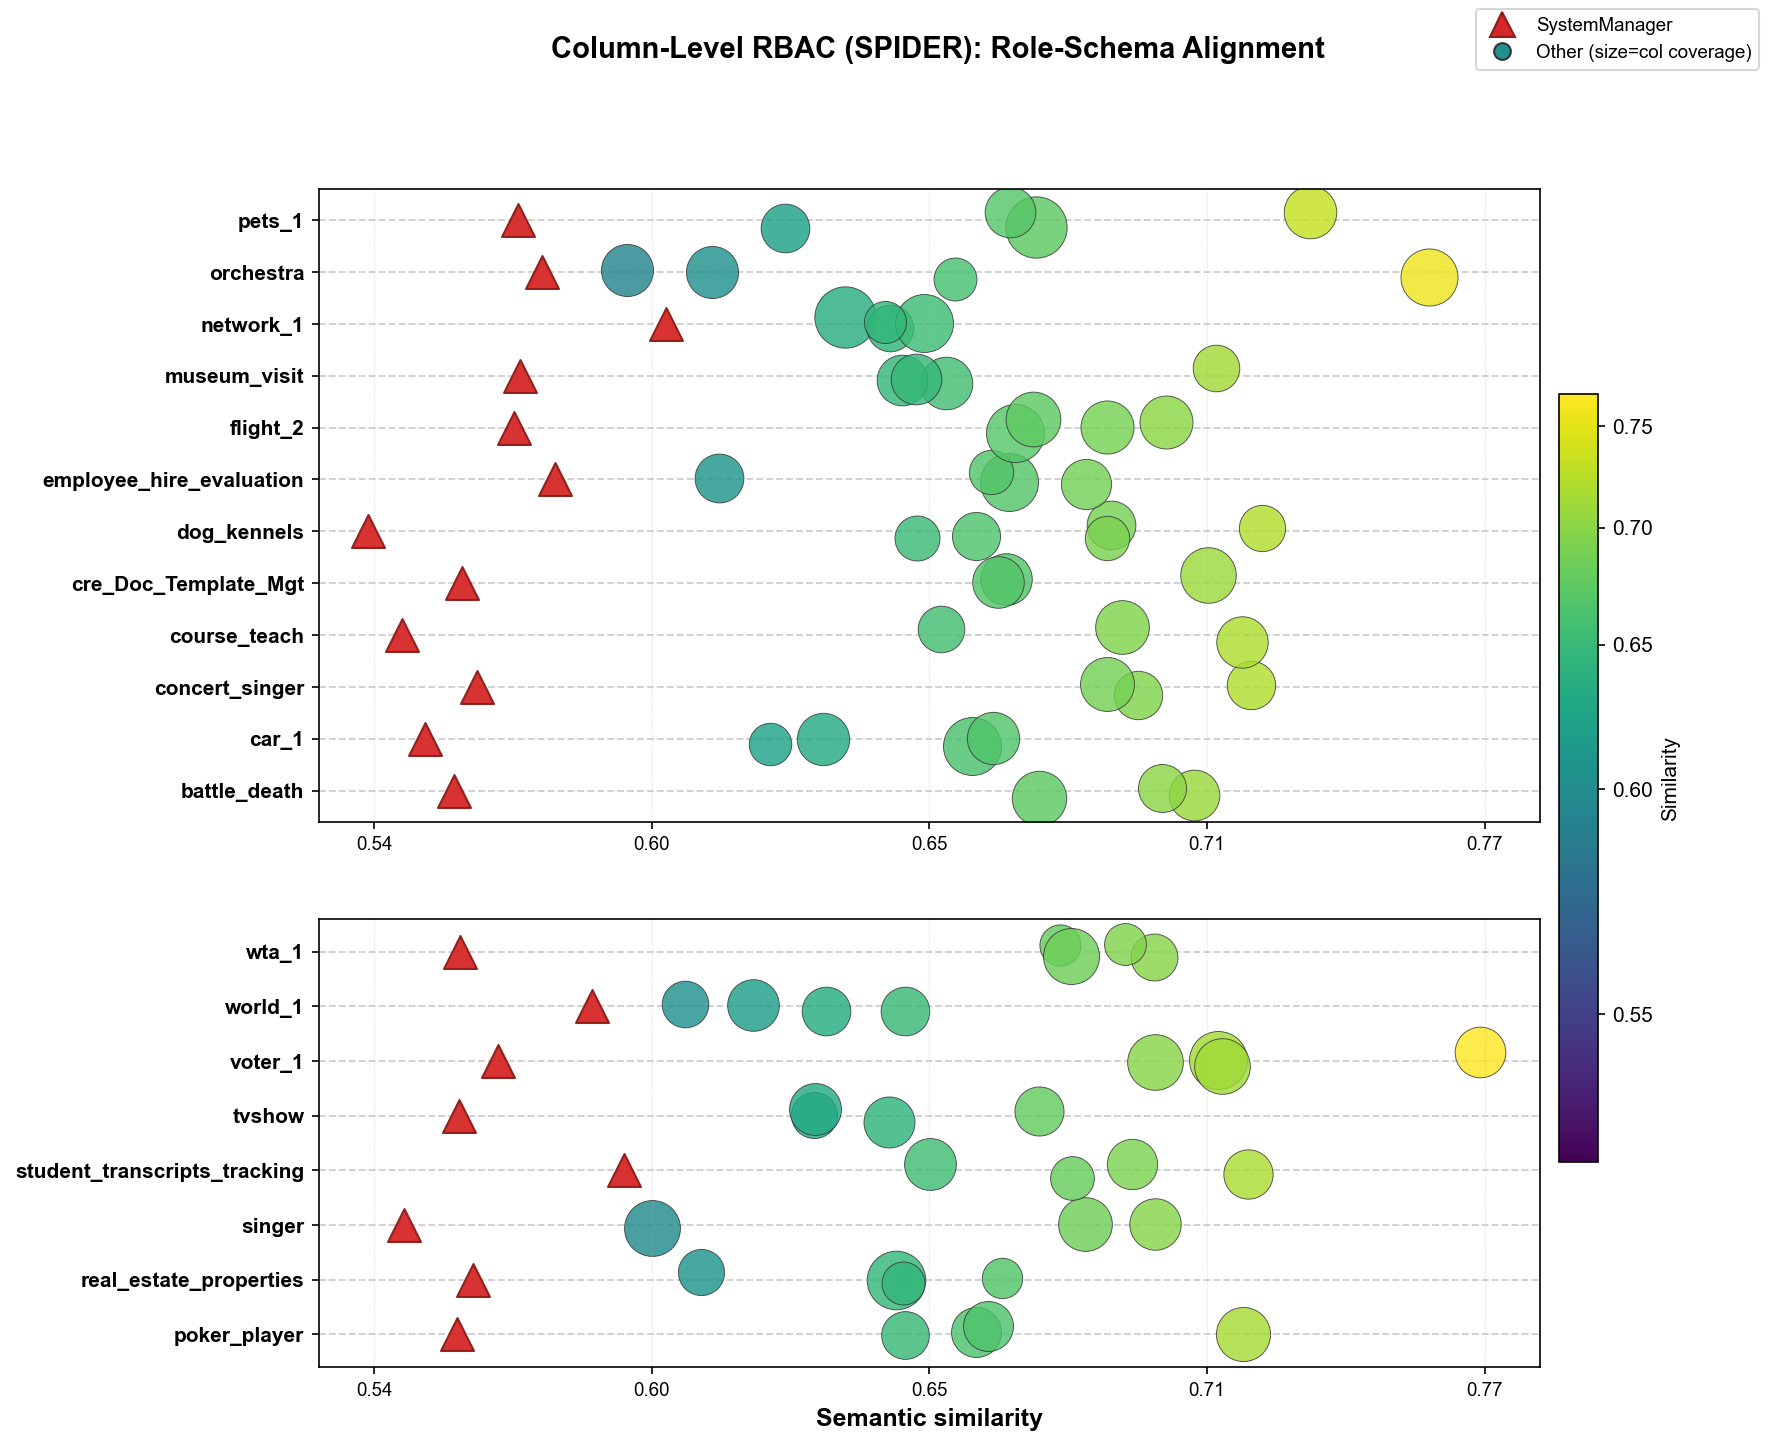

In [103]:
# 5.4 Semantic Alignment Visualization
# Circle size = column coverage, Red triangles = SystemManager
import random
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib import colormaps as cm
from collections import defaultdict
from matplotlib.lines import Line2D

sys.path.insert(0, str(project_root / "plot"))
from embedding_utils import cosine_similarity

if 'evaluator' in dir():
    # Prepare records
    role_records = evaluator._prepare_role_records()
    evaluator._compute_embeddings()
    
    # Build vis_records with is_system_manager
    vis_records = []
    for spec in role_records:
        schema_emb = evaluator._schema_emb_dict.get(spec["schema_text"])
        role_emb = evaluator._role_emb_dict.get(spec["role_text"])
        
        if schema_emb is not None and role_emb is not None:
            raw_sim = cosine_similarity(role_emb, schema_emb)
            similarity = max(0.0, min(1.0, (raw_sim + 1.0) / 2.0))
        else:
            similarity = 0.5
        
        total_cols = spec.get("total_columns", 1)
        accessible_cols = spec.get("accessible_columns", 0)
        col_coverage = accessible_cols / total_cols if total_cols > 0 else 0
        
        vis_records.append({
            "db_id": spec["db_id"],
            "role": spec["role"],
            "similarity": similarity,
            "is_system_manager": spec.get("is_system_manager", False),
            "column_coverage": col_coverage,
        })
    
    sm_count = sum(1 for r in vis_records if r["is_system_manager"])
    print(f"Total roles: {len(vis_records)}, SystemManager: {sm_count}")
    
    # Plot function
    def plot_semantic_spider(records, output_path, title, dbs_per_panel=12):
        db_to_entries = defaultdict(list)
        sims = []
        for rec in records:
            sims.append(rec["similarity"])
            size = 90.0 + rec["column_coverage"] * 220.0
            db_to_entries[rec["db_id"]].append({
                "sim": rec["similarity"], "size": size,
                "is_sm": rec["is_system_manager"],
            })
        
        db_ids = sorted(db_to_entries.keys())
        panels = [db_ids[i:i+dbs_per_panel] for i in range(0, len(db_ids), dbs_per_panel)]
        
        min_s, max_s = min(sims), max(sims)
        if math.isclose(min_s, max_s): max_s = min_s + 1e-6
        span = max_s - min_s
        norm = PowerNorm(gamma=0.55, vmin=min_s, vmax=max_s)
        cmap = cm["viridis"]
        
        fig = plt.figure(figsize=(11, sum(0.35*len(p)+0.6 for p in panels)+2))
        gs = fig.add_gridspec(len(panels), 1, height_ratios=[0.35*len(p)+0.6 for p in panels], hspace=0.18)
        axes = []
        
        random.seed(42)
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])
        
        for pi, chunk in enumerate(panels):
            ax = fig.add_subplot(gs[pi, 0])
            axes.append(ax)
            for ri, db in enumerate(chunk):
                y = float(ri)
                ax.axhline(y, color="#d0d0d0", linestyle="--", lw=0.9, zorder=0)
                for e in db_to_entries[db]:
                    x = (e["sim"] - min_s) / span + random.uniform(-0.012, 0.012)
                    if e["is_sm"]:
                        ax.scatter(x, y, s=250, c="#d62728", alpha=0.95,
                                   edgecolors="#8c1c15", lw=1.0, marker="^", zorder=4)
                    else:
                        ax.scatter(x, y + random.uniform(-0.16, 0.16), s=e["size"]*2.5,
                                   c=[e["sim"]], cmap=cmap, norm=norm, alpha=0.82,
                                   edgecolors="#333", lw=0.45, marker="o")
            ax.set_yticks(range(len(chunk)))
            ax.set_yticklabels(chunk, fontsize=10, weight='bold')
            ax.set_xlim(-0.05, 1.05)
            ax.set_ylim(-0.6, len(chunk)-0.4)
            ax.set_xticks(np.linspace(0, 1, 5))
            ax.set_xticklabels([f"{min_s + p*span:.2f}" for p in np.linspace(0,1,5)], fontsize=9)
            ax.grid(axis="x", ls=":", lw=0.5, alpha=0.45)
        
        axes[-1].set_xlabel("Semantic similarity", fontsize=12, weight='bold')
        fig.suptitle(f"{title}: Role-Schema Alignment", fontsize=14, y=0.98, weight='bold')
        cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.015)
        cbar.set_label("Similarity", fontsize=10)
        
        legend = [
            Line2D([0],[0], marker='^', color='w', markerfacecolor='#d62728',
                   markeredgecolor='#8c1c15', markersize=12, label='SystemManager'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='#21918c',
                   markeredgecolor='#333', markersize=8, label='Other (size=col coverage)'),
        ]
        fig.legend(handles=legend, loc='upper right', fontsize=9)
        plt.tight_layout(rect=[0,0,0.95,0.95])
        fig.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"Saved: {output_path}")
    
    output_path = project_root / "plot" / "column_level_rbac_semantic_spider.png"
    plot_semantic_spider(vis_records, output_path, "Column-Level RBAC (SPIDER)")
    from IPython.display import Image
    display(Image(filename=str(output_path)))
else:
    print("⚠️ Run quality evaluation first")

In [104]:
# 5.5 Export Problematic Databases (with custom thresholds)

# Set display options for full content (no truncation)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

# Re-evaluate issues with custom thresholds
def check_issues_custom(db_id, report, thresholds):
    """Check if database has issues based on custom thresholds."""
    issues = []
    
    if db_id in report.deny_rate_metrics:
        m = report.deny_rate_metrics[db_id]
        if m.deny_rate < thresholds["deny_rate_min"]:
            issues.append(f"Low deny rate ({m.deny_rate:.1f}% < {thresholds['deny_rate_min']}%)")
    
    if db_id in report.semantic_metrics:
        m = report.semantic_metrics[db_id]
        if m.avg_coverage > thresholds["coverage_max"]:
            issues.append(f"High coverage ({m.avg_coverage:.1%} > {thresholds['coverage_max']:.0%})")
        if m.coverage_std < thresholds["coverage_std_min"]:
            issues.append(f"Low diversity (std={m.coverage_std:.3f} < {thresholds['coverage_std_min']})")
    
    if db_id in report.overlap_metrics:
        m = report.overlap_metrics[db_id]
        if m.max_overlap > thresholds["max_overlap"]:
            issues.append(f"High overlap ({m.max_overlap:.1%} > {thresholds['max_overlap']:.0%})")
    
    return issues

if 'report' in dir():
    # Re-check all databases with custom thresholds
    issues_data = []
    problematic_dbs = []
    
    all_dbs = set(report.deny_rate_metrics.keys()) | set(report.semantic_metrics.keys()) | set(report.overlap_metrics.keys())
    
    for db_id in sorted(all_dbs):
        issues = check_issues_custom(db_id, report, QUALITY_THRESHOLDS)
        
        row = {"Database": db_id}
        
        if db_id in report.deny_rate_metrics:
            m = report.deny_rate_metrics[db_id]
            row["Deny%"] = f"{m.deny_rate:.1f}%"
            row["AllAllow%"] = f"{m.all_allow_pct:.1f}%"
        
        if db_id in report.semantic_metrics:
            m = report.semantic_metrics[db_id]
            row["Coverage"] = f"{m.avg_coverage:.1%}"
            row["CovStd"] = f"{m.coverage_std:.3f}"
        
        if db_id in report.overlap_metrics:
            m = report.overlap_metrics[db_id]
            row["MaxOverlap"] = f"{m.max_overlap:.1%}"
        
        row["Issues"] = "; ".join(issues) if issues else "OK"
        row["Status"] = "WARN" if issues else "OK"
        
        if issues:
            problematic_dbs.append(db_id)
        
        issues_data.append(row)
    
    issues_df = pd.DataFrame(issues_data)
    
    print(f"=== Quality Check with Custom Thresholds ===")
    print(f"Pass Rate: {len(all_dbs) - len(problematic_dbs)}/{len(all_dbs)} ({(len(all_dbs) - len(problematic_dbs))/len(all_dbs):.1%})")
    print(f"\nThresholds:")
    for k, v in QUALITY_THRESHOLDS.items():
        print(f"  {k}: {v}")
    
    print(f"\n=== All Databases ({len(issues_df)}) ===")
    display(issues_df)
    
    if problematic_dbs:
        print(f"\n[WARN] {len(problematic_dbs)} database(s) need review: {problematic_dbs}")
    else:
        print("\n[OK] All databases pass quality checks!")
else:
    print("[INFO] Run quality evaluation first (Cell above)")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')

=== Quality Check with Custom Thresholds ===
Pass Rate: 20/20 (100.0%)

Thresholds:
  deny_rate_min: 5.0
  coverage_max: 0.9
  coverage_std_min: 0.065
  max_overlap: 0.9

=== All Databases (20) ===


,Database,Deny%,AllAllow%,Coverage,CovStd,MaxOverlap,Issues,Status
0,battle_death,39.1%,12.5%,68.5%,0.114,58.8%,OK,OK
1,car_1,27.8%,6.5%,70.7%,0.233,88.9%,OK,OK
2,concert_singer,31.1%,13.3%,65.1%,0.112,52.6%,OK,OK
3,course_teach,50.0%,6.7%,66.7%,0.125,71.4%,OK,OK
4,cre_Doc_Template_Mgt,12.5%,59.5%,76.5%,0.083,53.3%,OK,OK
5,dog_kennels,52.4%,2.4%,49.8%,0.067,74.1%,OK,OK
6,employee_hire_evaluation,33.7%,15.8%,66.2%,0.214,64.7%,OK,OK
7,flight_2,25.0%,47.5%,84.6%,0.094,81.8%,OK,OK
8,museum_visit,54.4%,11.1%,64.6%,0.091,88.9%,OK,OK
9,network_1,39.3%,7.1%,75.0%,0.344,85.7%,OK,OK



[OK] All databases pass quality checks!


## 6. Regenerate Roles for Problematic Databases

Human-in-the-loop workflow for fixing quality issues:

| Step | Cell | Description |
|------|------|-------------|
| 1 | 6.1 | Select database, view schema and current roles |
| 2 | 6.2 | Write regeneration hints (edit manually) |
| 3 | 6.3 | Execute regeneration with LLM |
| 4 | 6.4 | Preview and compare OLD vs NEW |
| 5 | 6.5 | Apply changes if satisfied |

In [31]:
# 6.1 Select Database(s) & View Current State
# Supports single db (str) or multiple dbs (list)

# "network_1",

TARGET_DBS = ["cre_Doc_Template_Mgt", "network_1"]  # Single: "network_1" or Multiple: ["network_1", "singer"]

# Normalize to list
if isinstance(TARGET_DBS, str):
    TARGET_DBS = [TARGET_DBS]

# Load current role assignments
with open(ROLE_ASSIGNMENTS_PATH, 'r') as f:
    all_assignments = json.load(f)

available_dbs = set(all_assignments.get('assignments', {}).keys())
valid_target_dbs = [db for db in TARGET_DBS if db in available_dbs]
invalid_dbs = [db for db in TARGET_DBS if db not in available_dbs]

if invalid_dbs:
    print(f"[WARN] Databases not found: {invalid_dbs}")
    print(f"Available: {sorted(available_dbs)}\n")

# Store schemas for later use
target_schemas = {}

for TARGET_DB in valid_target_dbs:
    print(f"\n{'='*70}")
    print(f"Database: {TARGET_DB}")
    print(f"{'='*70}")
    
    # --- Schema Summary ---
    db_path = SPIDER_DB_DIR / TARGET_DB / f"{TARGET_DB}.sqlite"
    if db_path.exists():
        target_schema = get_schema_from_sqlite(str(db_path))
        target_schemas[TARGET_DB] = target_schema
        
        schema_rows = []
        for table, info in target_schema.items():
            for col in info['columns']:
                schema_rows.append({
                    "Table": table,
                    "Column": col['name'],
                    "Type": col['type'],
                    "PK": "Yes" if col['pk'] else "",
                    "FK": col.get('fk', '') or ""
                })
        
        schema_df = pd.DataFrame(schema_rows)
        print(f"\n=== Schema ({len(target_schema)} tables, {len(schema_df)} columns) ===")
        display(schema_df)
    else:
        print(f"[ERROR] Database not found: {db_path}")
        target_schemas[TARGET_DB] = None
        continue

    # --- Current Roles ---
    if TARGET_DB in all_assignments.get('assignments', {}):
        current_roles = all_assignments['assignments'][TARGET_DB]
        
        # Set display options for full content
        pd.set_option('display.max_colwidth', None)
        
        roles_rows = []
        for role_info in current_roles:
            policy = role_info.get('policy', {})
            total_access = count_policy_columns(policy, target_schema)
            has_wildcard = has_wildcard_policy(policy)
            cols_display = f"{total_access}" + (" (*)" if has_wildcard else "")
            # Full policy string (same format as Cell 6.4)
            policy_str = "; ".join([
                f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" 
                for t, c in policy.items()
            ])
            roles_rows.append({
                "Role": role_info['role'],
                "Description": role_info.get('description', ''),
                "Tables": len(policy),
                "Columns": cols_display,
                "Policy": policy_str  # Full policy, no truncation
            })
        
        roles_df = pd.DataFrame(roles_rows)
        print(f"\n=== Current Roles ({len(current_roles)}) ===")
        display(roles_df)
        
        pd.reset_option('display.max_colwidth')
        
        # Policy detail matrix
        policy_rows = []
        for role_info in current_roles:
            policy = role_info.get('policy', {})
            for table, cols in policy.items():
                num_cols = count_policy_columns({table: cols}, target_schema)
                policy_rows.append({
                    "Role": role_info['role'],
                    "Table": table,
                    "NumCols": num_cols
                })
        
        if policy_rows:
            policy_df = pd.DataFrame(policy_rows)
            pivot = policy_df.pivot_table(index='Role', columns='Table', values='NumCols', fill_value=0)
            print("\n=== Role x Table Matrix (column counts, * expanded) ===")
            display(pivot.style.background_gradient(cmap='Blues', axis=None))
        
        # Quality issues
        if 'report' in dir() and TARGET_DB in report.all_issues:
            print(f"\n=== Quality Issues ===")
            issues = report.all_issues[TARGET_DB]
            if TARGET_DB in report.deny_rate_metrics:
                m = report.deny_rate_metrics[TARGET_DB]
                issues_df = pd.DataFrame([{
                    "Deny Rate": f"{m.deny_rate:.1f}%",
                    "All-Allow %": f"{m.all_allow_pct:.1f}%",
                    "Issues": "; ".join(issues)
                }])
                display(issues_df)
    else:
        print(f"[ERROR] No roles found for {TARGET_DB}")

print(f"\n{'='*70}")
print(f"[SUMMARY] {len(valid_target_dbs)} database(s) selected: {valid_target_dbs}")
print("[NEXT] Edit hints in Cell 6.2, then run Cell 6.3")


Database: cre_Doc_Template_Mgt

=== Schema (4 tables, 17 columns) ===


,Table,Column,Type,PK,FK
0,Ref_Template_Types,Template_Type_Code,CHAR(15),Yes,
1,Ref_Template_Types,Template_Type_Description,VARCHAR(255),,
2,Templates,Template_ID,INTEGER,Yes,
3,Templates,Version_Number,INTEGER,,
4,Templates,Template_Type_Code,CHAR(15),,Ref_Template_Types.Template_Type_Code
5,Templates,Date_Effective_From,DATETIME,,
6,Templates,Date_Effective_To,DATETIME,,
7,Templates,Template_Details,VARCHAR(255),,
8,Documents,Document_ID,INTEGER,Yes,
9,Documents,Template_ID,INTEGER,,Templates.Template_ID



=== Current Roles (5) ===


,Role,Description,Tables,Columns,Policy
0,TemplateDesigner,Creates and manages document templates and template types,4,12 (*),"Ref_Template_Types: [*]; Templates: [Template_ID, Version_Number, Template_Type_Code, Date_Effective_From, Date_Effective_To, Template_Details]; Documents: [Document_ID, Template_ID, Document_Name, Document_Description]; Paragraphs: []"
1,DocumentAuthor,Creates documents using existing templates and writes paragraph content,4,15,"Ref_Template_Types: [Template_Type_Code, Template_Type_Description]; Templates: [Template_ID, Version_Number, Template_Type_Code, Template_Details]; Documents: [Document_ID, Template_ID, Document_Name, Document_Description, Other_Details]; Paragraphs: [Paragraph_ID, Document_ID, Paragraph_Text, Other_Details]"
2,DocumentReviewer,Reviews existing documents and their content without modification rights,4,12,"Ref_Template_Types: [Template_Type_Code, Template_Type_Description]; Templates: [Template_ID, Template_Type_Code, Template_Details]; Documents: [Document_ID, Template_ID, Document_Name, Document_Description]; Paragraphs: [Paragraph_ID, Document_ID, Paragraph_Text]"
3,ComplianceOfficer,Monitors template effectiveness dates and document compliance,4,10,"Ref_Template_Types: [Template_Type_Code, Template_Type_Description]; Templates: [Template_ID, Template_Type_Code, Date_Effective_From, Date_Effective_To, Template_Details]; Documents: [Document_ID, Template_ID, Document_Name]; Paragraphs: []"
4,SystemManager,Full administrative access for system maintenance and configuration,4,17 (*),Ref_Template_Types: [*]; Templates: [*]; Documents: [*]; Paragraphs: [*]



=== Role x Table Matrix (column counts, * expanded) ===


...


=== Role x Table Matrix (column counts, * expanded) ===


Table,Friend,Highschooler,Likes
Role,,,
RelationshipAnalyst,2.000000,2.000000,2.000000
StudentDirectoryManager,0.000000,3.000000,0.000000
SystemManager,2.000000,3.000000,2.000000



=== Quality Issues ===


,Deny Rate,All-Allow %,Issues
0,0.0%,100.0%,deny rate too low (0.0% < 5.0%)



[SUMMARY] 2 database(s) selected: ['cre_Doc_Template_Mgt', 'network_1']
[NEXT] Edit hints in Cell 6.2, then run Cell 6.3


In [32]:
# 6.2 Write Regeneration Hints (Human-in-the-Loop)
# Write ONE shared hint for all selected databases (they have similar issues)

# ============================================================
# EDIT HERE: Shared problem description for all selected DBs
# Supports {db}, {num_tables}, {num_cols} placeholders
# ============================================================



# PROBLEM_TO_FIX = """
# [PROBLEM]
# Low diversity - all roles have similar access patterns (coverage_std too low)

# [ROOT CAUSE]
# - This defeats the purpose of RBAC - no meaningful access control differentiation

# [DIRECTION]
# - Database: {db} ({num_tables} tables, {num_cols} columns)
# - Create restrictive roles that only access specific subsets of data
# - Each role should have a clear, limited scope
# - Some roles should be restricted to fewer tables
# - Do not frequently giving non-admin roles "*" (all columns) access
# - Create clear functional boundaries between roles
# """

PROBLEM_TO_FIX = """
[PROBLEM]
Low deny rate - almost all queries are allowed by all roles (roles too permissive)

[ROOT CAUSE]
- Most roles can access most/all columns, so very few queries get denied
- This defeats the purpose of RBAC - no meaningful access control

[DIRECTION]
- Database: {db} ({num_tables} tables, {num_cols} columns)
- Target deny rate: 30-50% (currently too low)
- Create at least 2-3 restrictive roles that can only access 30-50% of columns
- Limit table access: some roles should only access 1-2 specific tables
- Do not frequently using "*" (all columns) - explicitly list only necessary columns
- Design roles based on realistic job functions with minimal privilege principle
"""


# ============================================================
# Auto-apply to all selected databases (no need to edit below)
# ============================================================
REGENERATION_HINTS = {}

print(f"=== Applying shared hint to {len(valid_target_dbs)} database(s) ===\n")
for db in valid_target_dbs:
    schema = target_schemas.get(db, {})
    num_tables = len(schema)
    num_cols = sum(len(t['columns']) for t in schema.values())
    
    # Fill placeholders
    REGENERATION_HINTS[db] = PROBLEM_TO_FIX.format(
        db=db, num_tables=num_tables, num_cols=num_cols
    )
    print(f"  ✓ {db}: {num_tables} tables, {num_cols} columns")

print(f"\n[NEXT] Run Cell 6.3 to regenerate all {len(valid_target_dbs)} database(s)")

=== Applying shared hint to 2 database(s) ===

  ✓ cre_Doc_Template_Mgt: 4 tables, 17 columns
  ✓ network_1: 3 tables, 7 columns

[NEXT] Run Cell 6.3 to regenerate all 2 database(s)


In [33]:
# 6.3 Execute Regeneration with Hints (supports multiple databases)

def regenerate_single_database(db_name: str, hint: str) -> dict:
    """Regenerate roles for a single database with guidance hints."""
    db_path = SPIDER_DB_DIR / db_name / f"{db_name}.sqlite"
    
    if not db_path.exists():
        return {"database": db_name, "status": "error", "error": "Database not found"}
    
    try:
        db_schema = get_schema_from_sqlite(str(db_path))
        db_schema_text = format_schema_for_prompt(db_schema, db_name)
        
        enhanced_system_prompt = f"{COLUMN_LEVEL_SYSTEM_PROMPT}\n\n[OPTIMIZATION GUIDANCE]\n{hint}"
        user_prompt = COLUMN_LEVEL_USER_PROMPT_TEMPLATE.format(schema_content=db_schema_text)
        
        response = oracle.query(
            prompt_sys=enhanced_system_prompt,
            prompt_user=user_prompt,
            temp=0.3,
            top_p=0.9,
            max_completion_tokens=DEFAULT_MAX_TOKENS
        )
        
        llm_response = response['answer']
        usage = response.get('usage', {})
        roles = parse_column_level_roles(llm_response)
        
        if not roles:
            return {"database": db_name, "status": "parse_error", 
                    "error": "Failed to parse LLM response", "raw_response": llm_response[:500]}
        
        validation = validate_roles_against_schema(roles, str(db_path))
        assignments = [{"role": r["role"], "description": r.get("description", ""), 
                       "policy": r.get("columns", {})} for r in roles]
        
        return {"database": db_name, "status": "success", "roles_count": len(assignments),
                "valid_roles": validation['valid_roles'], "all_valid": validation['all_valid'],
                "assignments": assignments, "usage": usage, "raw_response": llm_response}
    except Exception as e:
        return {"database": db_name, "status": "error", "error": str(e)}

# Execute for all target databases
print(f"Regenerating roles for {len(valid_target_dbs)} database(s)...")
print("="*60)

regenerated_results = {}  # Store all results
all_success = True

for db_name in valid_target_dbs:
    hint = REGENERATION_HINTS.get(db_name, PROBLEM_TO_FIX)
    print(f"\n[{db_name}] Generating...")
    
    result = regenerate_single_database(db_name, hint)
    regenerated_results[db_name] = result
    
    if result["status"] == "success":
        print(f"  ✓ {result['roles_count']} roles ({result['valid_roles']} valid)")
    else:
        print(f"  ✗ {result.get('error', result['status'])}")
        all_success = False

# Summary table
print("\n" + "="*60)
result_df = pd.DataFrame([{
    "Database": r["database"],
    "Status": r["status"],
    "Roles": r.get("roles_count", "N/A"),
    "Valid": r.get("valid_roles", "N/A"),
    "Tokens": r.get("usage", {}).get("total_tokens", "N/A")
} for r in regenerated_results.values()])
display(result_df)

if all_success:
    print("\n[OK] All databases regenerated. Run Cell 6.4 to preview.")
else:
    print("\n[WARN] Some databases failed. Check errors above.")

Regenerating roles for 2 database(s)...

[cre_Doc_Template_Mgt] Generating...
  ✓ 4 roles (4 valid)

[network_1] Generating...
  ✓ 5 roles (5 valid)



,Database,Status,Roles,Valid,Tokens
0,cre_Doc_Template_Mgt,success,4,4,1571
1,network_1,success,5,5,1338



[OK] All databases regenerated. Run Cell 6.4 to preview.


In [34]:
# 6.4 Preview Regenerated Roles (Compare OLD vs NEW + Quality Check)
# Supports multiple databases

from src.role_evaluator.quality_metrics import RoleQualityEvaluator

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

if 'regenerated_results' in dir() and regenerated_results:
    for db_name, regen_result in regenerated_results.items():
        if regen_result["status"] != "success":
            print(f"\n{'='*70}")
            print(f"[SKIP] {db_name}: {regen_result.get('error', 'failed')}")
            continue
        
        regenerated_assignments = regen_result["assignments"]
        target_schema = target_schemas.get(db_name)
        
        print(f"\n{'='*70}")
        print(f"Database: {db_name}")
        print(f"{'='*70}")
        
        # --- NEW Role Summary ---
        new_summary = []
        for r in regenerated_assignments:
            policy = r.get('policy', {})
            total_cols = count_policy_columns(policy, target_schema)
            has_wc = has_wildcard_policy(policy)
            cols_display = f"{total_cols}" + (" (*)" if has_wc else "")
            policy_str = "; ".join([
                f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" 
                for t, c in policy.items()
            ])
            new_summary.append({
                "Role": r['role'],
                "Description": r.get('description', ''),
                "Tables": len(policy),
                "Cols": cols_display,
                "Policy": policy_str  # Full policy, no truncation
            })
        
        print(f"\n=== NEW Roles ({len(regenerated_assignments)}) ===")
        display(pd.DataFrame(new_summary))
        
        # --- Quality Metrics ---
        if target_schema:
            total_schema_cols = sum(len(t['columns']) for t in target_schema.values())
        else:
            total_schema_cols = 10
        
        # NEW metrics
        new_coverages = [count_policy_columns(r.get('policy', {}), target_schema) / total_schema_cols 
                        for r in regenerated_assignments]
        new_avg_cov = np.mean(new_coverages)
        new_cov_std = np.std(new_coverages)
        
        new_max_overlap = 0.0
        non_admin_new = [r for r in regenerated_assignments if 'admin' not in r['role'].lower()]
        for i, r1 in enumerate(non_admin_new):
            set1 = RoleQualityEvaluator.policy_to_column_set(r1.get('policy', {}))
            for r2 in non_admin_new[i+1:]:
                set2 = RoleQualityEvaluator.policy_to_column_set(r2.get('policy', {}))
                new_max_overlap = max(new_max_overlap, RoleQualityEvaluator.jaccard_similarity(set1, set2))
        
        # OLD metrics
        old_roles = all_assignments.get('assignments', {}).get(db_name, [])
        if old_roles:
            old_coverages = [count_policy_columns(r.get('policy', {}), target_schema) / total_schema_cols 
                           for r in old_roles]
            old_avg_cov = np.mean(old_coverages)
            old_cov_std = np.std(old_coverages)
            
            old_max_overlap = 0.0
            non_admin_old = [r for r in old_roles if 'admin' not in r['role'].lower()]
            for i, r1 in enumerate(non_admin_old):
                set1 = RoleQualityEvaluator.policy_to_column_set(r1.get('policy', {}))
                for r2 in non_admin_old[i+1:]:
                    set2 = RoleQualityEvaluator.policy_to_column_set(r2.get('policy', {}))
                    old_max_overlap = max(old_max_overlap, RoleQualityEvaluator.jaccard_similarity(set1, set2))
        else:
            old_avg_cov, old_cov_std, old_max_overlap = 0, 0, 0
        
        # Comparison table (using QUALITY_THRESHOLDS from Cell 5.1)
        def status(metric, val):
            if metric == "Coverage": 
                return "WARN" if val > QUALITY_THRESHOLDS.get("coverage_max", 0.90) else "OK"
            if metric == "CovStd": 
                return "WARN" if val < QUALITY_THRESHOLDS.get("coverage_std_min", 0.08) else "OK"
            if metric == "MaxOverlap": 
                return "WARN" if val > QUALITY_THRESHOLDS.get("max_overlap", 0.85) else "OK"
            return "OK"
        
        quality_df = pd.DataFrame([
            {"Metric": "Roles", "OLD": len(old_roles), "NEW": len(regenerated_assignments)},
            {"Metric": "Avg Coverage", "OLD": f"{old_avg_cov:.1%}", "NEW": f"{new_avg_cov:.1%}", 
             "Threshold": f"<{QUALITY_THRESHOLDS.get('coverage_max', 0.90):.0%}",
             "Status": status("Coverage", new_avg_cov)},
            {"Metric": "Coverage Std", "OLD": f"{old_cov_std:.3f}", "NEW": f"{new_cov_std:.3f}",
             "Threshold": f">{QUALITY_THRESHOLDS.get('coverage_std_min', 0.08)}",
             "Status": status("CovStd", new_cov_std)},
            {"Metric": "Max Overlap", "OLD": f"{old_max_overlap:.1%}", "NEW": f"{new_max_overlap:.1%}",
             "Threshold": f"<{QUALITY_THRESHOLDS.get('max_overlap', 0.85):.0%}",
             "Status": status("MaxOverlap", new_max_overlap)},
        ])
        print("\n=== Quality Comparison ===")
        display(quality_df)
        
        warn_count = quality_df['Status'].eq('WARN').sum() if 'Status' in quality_df.columns else 0
        if warn_count == 0:
            print(f"[OK] {db_name}: All quality checks passed")
        else:
            print(f"[WARN] {db_name}: {warn_count} issue(s)")
    
    print(f"\n{'='*70}")
    print("[DECISION] Satisfied? Run Cell 6.5 to apply. Otherwise edit Cell 6.2 and re-run 6.3.")
else:
    print("[WARN] No regenerated results. Run Cell 6.3 first.")

pd.reset_option('display.max_colwidth')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')


Database: cre_Doc_Template_Mgt

=== NEW Roles (4) ===


,Role,Description,Tables,Cols,Policy
0,TemplateDesigner,Creates and manages document templates and template types,4,12 (*),"Ref_Template_Types: [*]; Templates: [Template_ID, Version_Number, Template_Type_Code, Date_Effective_From, Date_Effective_To, Template_Details]; Documents: [Document_ID, Template_ID, Document_Name, Document_Description]; Paragraphs: []"
1,DocumentEditor,Creates and edits documents and paragraphs using existing templates,4,15 (*),"Ref_Template_Types: [Template_Type_Code, Template_Type_Description]; Templates: [Template_ID, Template_Type_Code, Date_Effective_From, Template_Details]; Documents: [*]; Paragraphs: [*]"
2,TemplateAuditor,Reviews template effectiveness and usage without modifying content,4,12,"Ref_Template_Types: [Template_Type_Code, Template_Type_Description]; Templates: [Template_ID, Version_Number, Template_Type_Code, Date_Effective_From, Date_Effective_To]; Documents: [Document_ID, Template_ID, Document_Name]; Paragraphs: [Paragraph_ID, Document_ID]"
3,SystemManager,Full administrative access for system maintenance and configuration,4,17 (*),Ref_Template_Types: [*]; Templates: [*]; Documents: [*]; Paragraphs: [*]



=== Quality Comparison ===


,Metric,OLD,NEW,Threshold,Status
0,Roles,5,4,NaN,NaN
1,Avg Coverage,77.6%,82.4%,<90%,OK
2,Coverage Std,0.146,0.125,>0.08,OK
3,Max Overlap,80.0%,53.3%,<90%,OK


[OK] cre_Doc_Template_Mgt: All quality checks passed

Database: network_1

=== NEW Roles (5) ===


,Role,Description,Tables,Cols,Policy
0,StudentCounselor,Manages student academic progress and social connections for counseling purposes,3,7,"Highschooler: [ID, name, grade]; Friend: [student_id, friend_id]; Likes: [student_id, liked_id]"
1,AcademicAdvisor,Focuses on academic performance and grade progression without access to social relationships,3,3,"Highschooler: [ID, name, grade]; Friend: []; Likes: []"
2,SocialCoordinator,Manages student social relationships and connections for event planning,3,6,"Highschooler: [ID, name]; Friend: [student_id, friend_id]; Likes: [student_id, liked_id]"
3,StudentPeer,Limited access for student peer mentors to view basic peer information only,3,2,"Highschooler: [ID, name]; Friend: []; Likes: []"
4,SystemManager,Full administrative access for system maintenance and data management,3,7 (*),Highschooler: [*]; Friend: [*]; Likes: [*]



=== Quality Comparison ===


,Metric,OLD,NEW,Threshold,Status
0,Roles,3,5,NaN,NaN
1,Avg Coverage,76.2%,71.4%,<90%,OK
2,Coverage Std,0.243,0.300,>0.08,OK
3,Max Overlap,28.6%,85.7%,<90%,OK


[OK] network_1: All quality checks passed

[DECISION] Satisfied? Run Cell 6.5 to apply. Otherwise edit Cell 6.2 and re-run 6.3.


In [35]:
# 6.4.1 Select & Combine Roles from OLD and NEW
# Human expert picks best roles from both versions to create final role set

# ============================================================
# EDIT HERE: Specify which roles to keep from each version
# Format: {"db_name": {"old": [role_names], "new": [role_names]}}
# Leave empty [] to skip a version, or use ["*"] to keep all from that version
# ============================================================
ROLE_SELECTION = {
    "cre_Doc_Template_Mgt": {
        "old": [],  
        "new": ["*"],
    },

    # "dog_kennels": {
    #     "old": [],  
    #     "new": ["*"],
    # },

    # "museum_visit": {
    #     "old": [],
    #     "new": ["*"],
    # },

    # "singer": {
    #     "old": [],  
    #     "new": ["FinancialAnalyst", "CatalogManager", "BusinessDevelopment", "SystemManager"],
    # },

    # "tvshow": {
    #     "old": [],
    #     "new": ["*"],
    # },
    # "world_1": {
    #     "old": [],
    #     "new": ["*"],
    # },

    "network_1": {
        "old": [],  # e.g., ["NetworkAdmin", "SecurityAnalyst"]
        # "new": ["StudentDirectoryManager", "RelationshipAnalyst", "SystemManager"], 
        "new": ["*"],  # keep all new roles
    },

}

# ============================================================
# Process selections and create combined role sets
# ============================================================
combined_results = {}

if 'regenerated_results' in dir() and regenerated_results:
    print("=== Role Selection Summary ===\n")
    
    for db_name in valid_target_dbs:
        selection = ROLE_SELECTION.get(db_name, {"old": [], "new": ["*"]})
        old_keep = selection.get("old", [])
        new_keep = selection.get("new", ["*"])
        
        # Get OLD roles
        old_roles = all_assignments.get('assignments', {}).get(db_name, [])
        old_role_dict = {r['role']: r for r in old_roles}
        
        # Get NEW roles
        regen_result = regenerated_results.get(db_name, {})
        if regen_result.get("status") != "success":
            print(f"[SKIP] {db_name}: regeneration failed")
            continue
        new_roles = regen_result["assignments"]
        new_role_dict = {r['role']: r for r in new_roles}
        
        # Build combined role set
        combined_roles = []
        selected_from_old = []
        selected_from_new = []
        
        # Select from OLD
        if old_keep == ["*"]:
            combined_roles.extend(old_roles)
            selected_from_old = [r['role'] for r in old_roles]
        else:
            for role_name in old_keep:
                if role_name in old_role_dict:
                    combined_roles.append(old_role_dict[role_name])
                    selected_from_old.append(role_name)
                else:
                    print(f"  [WARN] {db_name}: OLD role '{role_name}' not found")
        
        # Select from NEW
        if new_keep == ["*"]:
            combined_roles.extend(new_roles)
            selected_from_new = [r['role'] for r in new_roles]
        else:
            for role_name in new_keep:
                if role_name in new_role_dict:
                    combined_roles.append(new_role_dict[role_name])
                    selected_from_new.append(role_name)
                else:
                    print(f"  [WARN] {db_name}: NEW role '{role_name}' not found")
        
        combined_results[db_name] = combined_roles
        
        # Display summary
        print(f"{'='*60}")
        print(f"Database: {db_name}")
        print(f"  From OLD ({len(selected_from_old)}): {selected_from_old if selected_from_old else '(none)'}")
        print(f"  From NEW ({len(selected_from_new)}): {selected_from_new if selected_from_new else '(none)'}")
        print(f"  Combined: {len(combined_roles)} roles")
        
        # Show combined roles table
        target_schema = target_schemas.get(db_name)
        combined_summary = []
        for r in combined_roles:
            policy = r.get('policy', {})
            source = "OLD" if r['role'] in old_role_dict and r['role'] not in [nr['role'] for nr in new_roles] else "NEW"
            if r['role'] in old_role_dict and r['role'] in [nr['role'] for nr in new_roles]:
                source = "NEW"  # Prefer NEW if same name exists in both
            combined_summary.append({
                "Source": source,
                "Role": r['role'],
                "Description": r.get('description', ''),
                "Tables": len(policy),
                "Policy": "; ".join([f"{t}: [{', '.join(c) if isinstance(c, list) else c}]" for t, c in policy.items()])
            })
        
        display(pd.DataFrame(combined_summary))
        print()
    
    print("="*60)
    print(f"[NEXT] Run Cell 6.5 to apply combined role sets")
    print("[TIP] Edit ROLE_SELECTION above to customize, then re-run this cell")
else:
    print("[WARN] No regenerated results. Run Cell 6.3 first.")
    print("\n[HINT] Available roles to select from:")
    print("  OLD: roles from current assignments")
    print("  NEW: roles from regeneration")

=== Role Selection Summary ===

Database: cre_Doc_Template_Mgt
  From OLD (0): (none)
  From NEW (4): ['TemplateDesigner', 'DocumentEditor', 'TemplateAuditor', 'SystemManager']
  Combined: 4 roles


,Source,Role,Description,Tables,Policy
0,NEW,TemplateDesigner,Creates and manages document templates and tem...,4,Ref_Template_Types: [*]; Templates: [Template_...
1,NEW,DocumentEditor,Creates and edits documents and paragraphs usi...,4,"Ref_Template_Types: [Template_Type_Code, Templ..."
2,NEW,TemplateAuditor,Reviews template effectiveness and usage witho...,4,"Ref_Template_Types: [Template_Type_Code, Templ..."
3,NEW,SystemManager,Full administrative access for system maintena...,4,Ref_Template_Types: [*]; Templates: [*]; Docum...



Database: network_1
  From OLD (0): (none)
  From NEW (5): ['StudentCounselor', 'AcademicAdvisor', 'SocialCoordinator', 'StudentPeer', 'SystemManager']
  Combined: 5 roles


,Source,Role,Description,Tables,Policy
0,NEW,StudentCounselor,Manages student academic progress and social c...,3,"Highschooler: [ID, name, grade]; Friend: [stud..."
1,NEW,AcademicAdvisor,Focuses on academic performance and grade prog...,3,"Highschooler: [ID, name, grade]; Friend: []; L..."
2,NEW,SocialCoordinator,Manages student social relationships and conne...,3,"Highschooler: [ID, name]; Friend: [student_id,..."
3,NEW,StudentPeer,Limited access for student peer mentors to vie...,3,"Highschooler: [ID, name]; Friend: []; Likes: []"
4,NEW,SystemManager,Full administrative access for system maintena...,3,Highschooler: [*]; Friend: [*]; Likes: [*]



[NEXT] Run Cell 6.5 to apply combined role sets
[TIP] Edit ROLE_SELECTION above to customize, then re-run this cell


In [40]:
# 6.5 Apply Changes (Save Combined Role Sets)
# Uses combined_results from Cell 6.4.1 (selected from OLD + NEW)

APPLY_CHANGES = True  # Set to True to confirm

if APPLY_CHANGES:
    # Prefer combined_results (from selection), fallback to regenerated_results
    use_combined = 'combined_results' in dir() and combined_results
    use_regenerated = 'regenerated_results' in dir() and regenerated_results
    
    if use_combined:
        print("[MODE] Applying COMBINED role sets (from Cell 6.4.1 selection)\n")
        applied = []
        
        for db_name, combined_roles in combined_results.items():
            if not combined_roles:
                continue
            
            old_count = len(all_assignments.get('assignments', {}).get(db_name, []))
            all_assignments['assignments'][db_name] = combined_roles
            applied.append({
                "Database": db_name,
                "Old Roles": old_count,
                "New Roles": len(combined_roles),
                "Source": "Combined (OLD+NEW)"
            })
        
        if applied:
            OUTPUT_DIR = project_root / 'outputs'
            output_path = OUTPUT_DIR / 'spider_column_level_rbac_assignments_v2.json'
            with open(output_path, 'w') as f:
                json.dump(all_assignments, f, indent=2, ensure_ascii=False)
            
            print("=== Changes Applied ===")
            display(pd.DataFrame(applied))
            print(f"\nSaved to: {output_path.name}")
            
            # Clear state
            combined_results = {}
            regenerated_results = {}
            print("\n[OK] State cleared. Select new database(s) to continue.")
        else:
            print("[WARN] No combined role sets to apply. Run Cell 6.4.1 first.")
    
    elif use_regenerated:
        print("[MODE] Applying ALL NEW roles (no selection made)\n")
        applied = []
        
        for db_name, regen_result in regenerated_results.items():
            if regen_result["status"] != "success":
                continue
            
            old_count = len(all_assignments.get('assignments', {}).get(db_name, []))
            all_assignments['assignments'][db_name] = regen_result["assignments"]
            applied.append({
                "Database": db_name,
                "Old Roles": old_count,
                "New Roles": len(regen_result["assignments"]),
                "Source": "All NEW"
            })
        
        if applied:
            OUTPUT_DIR = project_root / 'outputs'
            output_path = OUTPUT_DIR / 'spider_column_level_rbac_assignments_v2.json'
            with open(output_path, 'w') as f:
                json.dump(all_assignments, f, indent=2, ensure_ascii=False)
            
            print("=== Changes Applied ===")
            display(pd.DataFrame(applied))
            print(f"\nSaved to: {output_path.name}")
            
            regenerated_results = {}
            print("\n[OK] State cleared. Select new database(s) to continue.")
        else:
            print("[WARN] No successful regenerations to apply.")
    else:
        print("[WARN] No results to apply. Run Cell 6.3 and optionally Cell 6.4.1 first.")
else:
    has_combined = 'combined_results' in dir() and combined_results
    has_regenerated = 'regenerated_results' in dir() and regenerated_results
    
    if has_combined:
        print(f"[INFO] {len(combined_results)} database(s) with COMBINED role sets ready")
        print("[TIP] These are your custom selections from OLD + NEW")
    elif has_regenerated:
        success_count = sum(1 for r in regenerated_results.values() if r["status"] == "success")
        print(f"[INFO] {success_count} database(s) with ALL NEW roles ready")
        print("[TIP] Run Cell 6.4.1 to select specific roles from OLD/NEW")
    
    print("\n[INFO] APPLY_CHANGES is False. Set to True and re-run to apply.")

[MODE] Applying COMBINED role sets (from Cell 6.4.1 selection)

=== Changes Applied ===


,Database,Old Roles,New Roles,Source
0,cre_Doc_Template_Mgt,5,4,Combined (OLD+NEW)
1,network_1,3,5,Combined (OLD+NEW)



Saved to: spider_column_level_rbac_assignments_v2.json

[OK] State cleared. Select new database(s) to continue.


In [44]:
# 6.6 Regenerate RBAC Dataset with Updated Role Assignments
# Run this after Cell 6.5 to create the final dataset

from datetime import datetime
import importlib
import src.processors.spider_column_level_rbac_generator
importlib.reload(src.processors.spider_column_level_rbac_generator)
from src.processors.spider_column_level_rbac_generator import SpiderColumnLevelRBACGenerator

# Find the updated role assignments file (v2 if exists, otherwise latest)
v2_path = project_root / 'outputs' / 'spider_column_level_rbac_assignments_v2.json'
if v2_path.exists():
    UPDATED_ROLE_PATH = str(v2_path)
else:
    role_files = sorted(glob.glob(str(project_root / 'outputs' / 'column_level_role_assignments_spider_*.json')))
    UPDATED_ROLE_PATH = role_files[-1] if role_files else None

if UPDATED_ROLE_PATH:
    print(f"=== Regenerating RBAC Dataset ===")
    print(f"Role assignments: {Path(UPDATED_ROLE_PATH).name}")
    print(f"Spider data: {SPIDER_DATA_PATH}")
    
    # Initialize generator with updated roles
    generator = SpiderColumnLevelRBACGenerator(
        role_assignments_path=UPDATED_ROLE_PATH,
        spider_data_path=str(SPIDER_DATA_PATH),
        spider_db_root=str(SPIDER_DB_DIR),
        project_root=str(project_root),
        seed=42
    )
    
    # Generate dataset
    today = datetime.now().strftime('%Y%m%d')
    output_path = project_root / 'outputs' / f'column_level_rbac_dataset_spider_{today}.json'
    
    full_stats = generator.generate_and_save(
        output_path=str(output_path),
        roles_per_db=None,
        queries_per_role=None
    )
    
    print(f"\n✓ Dataset saved to: {output_path.name}")
    print(f"\n=== Dataset Statistics ===")
    for k, v in full_stats.items():
        if k == 'by_database':
            print(f"\nPer-database distribution:")
            for db_id, counts in sorted(v.items()):
                print(f"  {db_id}: allowed={counts['allowed']}, denied={counts['denied']}")
        else:
            print(f"  {k}: {v}")
else:
    print("[ERROR] No role assignments file found. Run Cell 6.5 first.")

=== Regenerating RBAC Dataset ===
Role assignments: spider_column_level_rbac_assignments_v2.json
Spider data: /home/feiy/Role-SQL-benchmark/data/spider/dev.json
Generating Spider column-level RBAC dataset...
  Roles per DB: all
  Queries per role: all

Dataset saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_spider_20251229.json
Metadata saved to /home/feiy/Role-SQL-benchmark/outputs/column_level_rbac_dataset_spider_20251229_metadata.json
  Total entries: 5047
  Allowed: 3266 (64.7%)
  Denied: 1781 (35.3%)
  Databases: 20

✓ Dataset saved to: column_level_rbac_dataset_spider_20251229.json

=== Dataset Statistics ===
  total_entries: 5047
  allowed: 3266
  denied: 1781
  allowed_ratio: 0.6471170992668912
  databases: 20

Per-database distribution:
  battle_death: allowed=39, denied=25
  car_1: allowed=332, denied=128
  concert_singer: allowed=124, denied=56
  course_teach: allowed=60, denied=60
  cre_Doc_Template_Mgt: allowed=294, denied=42
  dog_kennels: allowed

## 7. Dataset Preview & Export

Final dataset statistics and sample previews.

In [56]:
# 7.1 Dataset Statistics Summary

print("=== Spider Column-Level RBAC Dataset Summary ===\n")

# Collect all role data
all_roles_data = []
for db_id, roles in all_assignments.get('assignments', {}).items():
    for role in roles:
        policy = role.get('policy', {})
        all_roles_data.append({
            "Database": db_id,
            "Role": role['role'],
            "Tables": len(policy),
            "IsAdmin": 'admin' in role['role'].lower()
        })

roles_df = pd.DataFrame(all_roles_data)
total_dbs = roles_df['Database'].nunique()

# Summary stats
summary_df = pd.DataFrame([
    {"Metric": "Databases", "Value": total_dbs},
    {"Metric": "Total Roles", "Value": len(roles_df)},
    {"Metric": "Avg Roles/DB", "Value": f"{len(roles_df)/total_dbs:.1f}"},
    {"Metric": "Admin Roles", "Value": roles_df['IsAdmin'].sum()},
])
display(summary_df)

# Role distribution per database
role_counts = roles_df.groupby('Database').size().reset_index(name='Roles')
print("\n=== Roles per Database ===")
display(role_counts.style.bar(subset=['Roles'], color='steelblue'))

# Table access distribution
table_dist = roles_df.groupby('Tables').size().reset_index(name='Count')
table_dist['Pct'] = (table_dist['Count'] / len(roles_df) * 100).round(1).astype(str) + '%'
print("\n=== Table Access Distribution ===")
display(table_dist)

=== Spider Column-Level RBAC Dataset Summary ===



,Metric,Value
0,Databases,20
1,Total Roles,96
2,Avg Roles/DB,4.8
3,Admin Roles,1



=== Roles per Database ===


,Database,Roles
0,battle_death,4
1,car_1,5
2,concert_singer,4
3,course_teach,4
4,cre_Doc_Template_Mgt,4
5,dog_kennels,6
6,employee_hire_evaluation,5
7,flight_2,5
8,museum_visit,5
9,network_1,5



=== Table Access Distribution ===


,Tables,Count,Pct
0,2,11,11.5%
1,3,58,60.4%
2,4,18,18.8%
3,5,2,2.1%
4,6,3,3.1%
5,8,2,2.1%
6,9,1,1.0%
7,11,1,1.0%


In [57]:
# 7.2 Sample Data Preview

import random

PREVIEW_COUNT = 3
db_list = list(all_assignments.get('assignments', {}).keys())
sample_dbs = random.sample(db_list, min(PREVIEW_COUNT, len(db_list)))

for db_id in sample_dbs:
    roles = all_assignments['assignments'][db_id]
    
    preview_rows = []
    for r in roles:
        policy = r.get('policy', {})
        tables = list(policy.keys())
        total_cols = sum(len(c) if isinstance(c, list) else 1 for c in policy.values())
        preview_rows.append({
            "Role": r['role'],
            "Description": r.get('description', '')[:35] + "..." if len(r.get('description', '')) > 35 else r.get('description', ''),
            "Tables": ", ".join(tables[:3]) + ("..." if len(tables) > 3 else ""),
            "TotalCols": total_cols
        })
    
    preview_df = pd.DataFrame(preview_rows)
    print(f"=== {db_id} ({len(roles)} roles) ===")
    display(preview_df)
    print()

print(f"[INFO] Showing {len(sample_dbs)} of {len(db_list)} databases")

=== orchestra (5 roles) ===


,Role,Description,Tables,TotalCols
0,OrchestraManager,"Manages orchestra operations, condu...","conductor, orchestra, performance...",21
1,FinancialAnalyst,"Analyzes financial performance, rat...","orchestra, performance, show",16
2,HRCoordinator,Manages conductor personnel records...,"conductor, orchestra",8
3,PublicRelations,Accesses public-facing information ...,"conductor, orchestra, performance...",16
4,SystemManager,Full administrative access for syst...,"conductor, orchestra, performance...",4



=== world_1 (5 roles) ===


,Role,Description,Tables,TotalCols
0,DemographicAnalyst,Analyzes population statistics and ...,"city, country, countrylanguage",14
1,EconomicResearcher,Studies economic indicators and dev...,"city, country, countrylanguage",17
2,GeographySpecialist,Focuses on geographic and administr...,"city, country, countrylanguage",14
3,HistoricalResearcher,Examines historical data including ...,"city, country, countrylanguage",12
4,SystemManager,Full administrative access for data...,"city, country, countrylanguage",3



=== student_transcripts_tracking (5 roles) ===


,Role,Description,Tables,TotalCols
0,AdmissionsOfficer,Manages student enrollment and basi...,"Addresses, Students, Student_Enrolment...",30
1,Registrar,"Manages course registration, transc...","Students, Courses, Sections...",28
2,AcademicAdvisor,Provides academic guidance and revi...,"Students, Courses, Sections...",33
3,Bursar,Handles student billing and financi...,"Addresses, Students",18
4,SystemManager,Full administrative access for syst...,"Addresses, Courses, Departments...",11



[INFO] Showing 3 of 20 databases


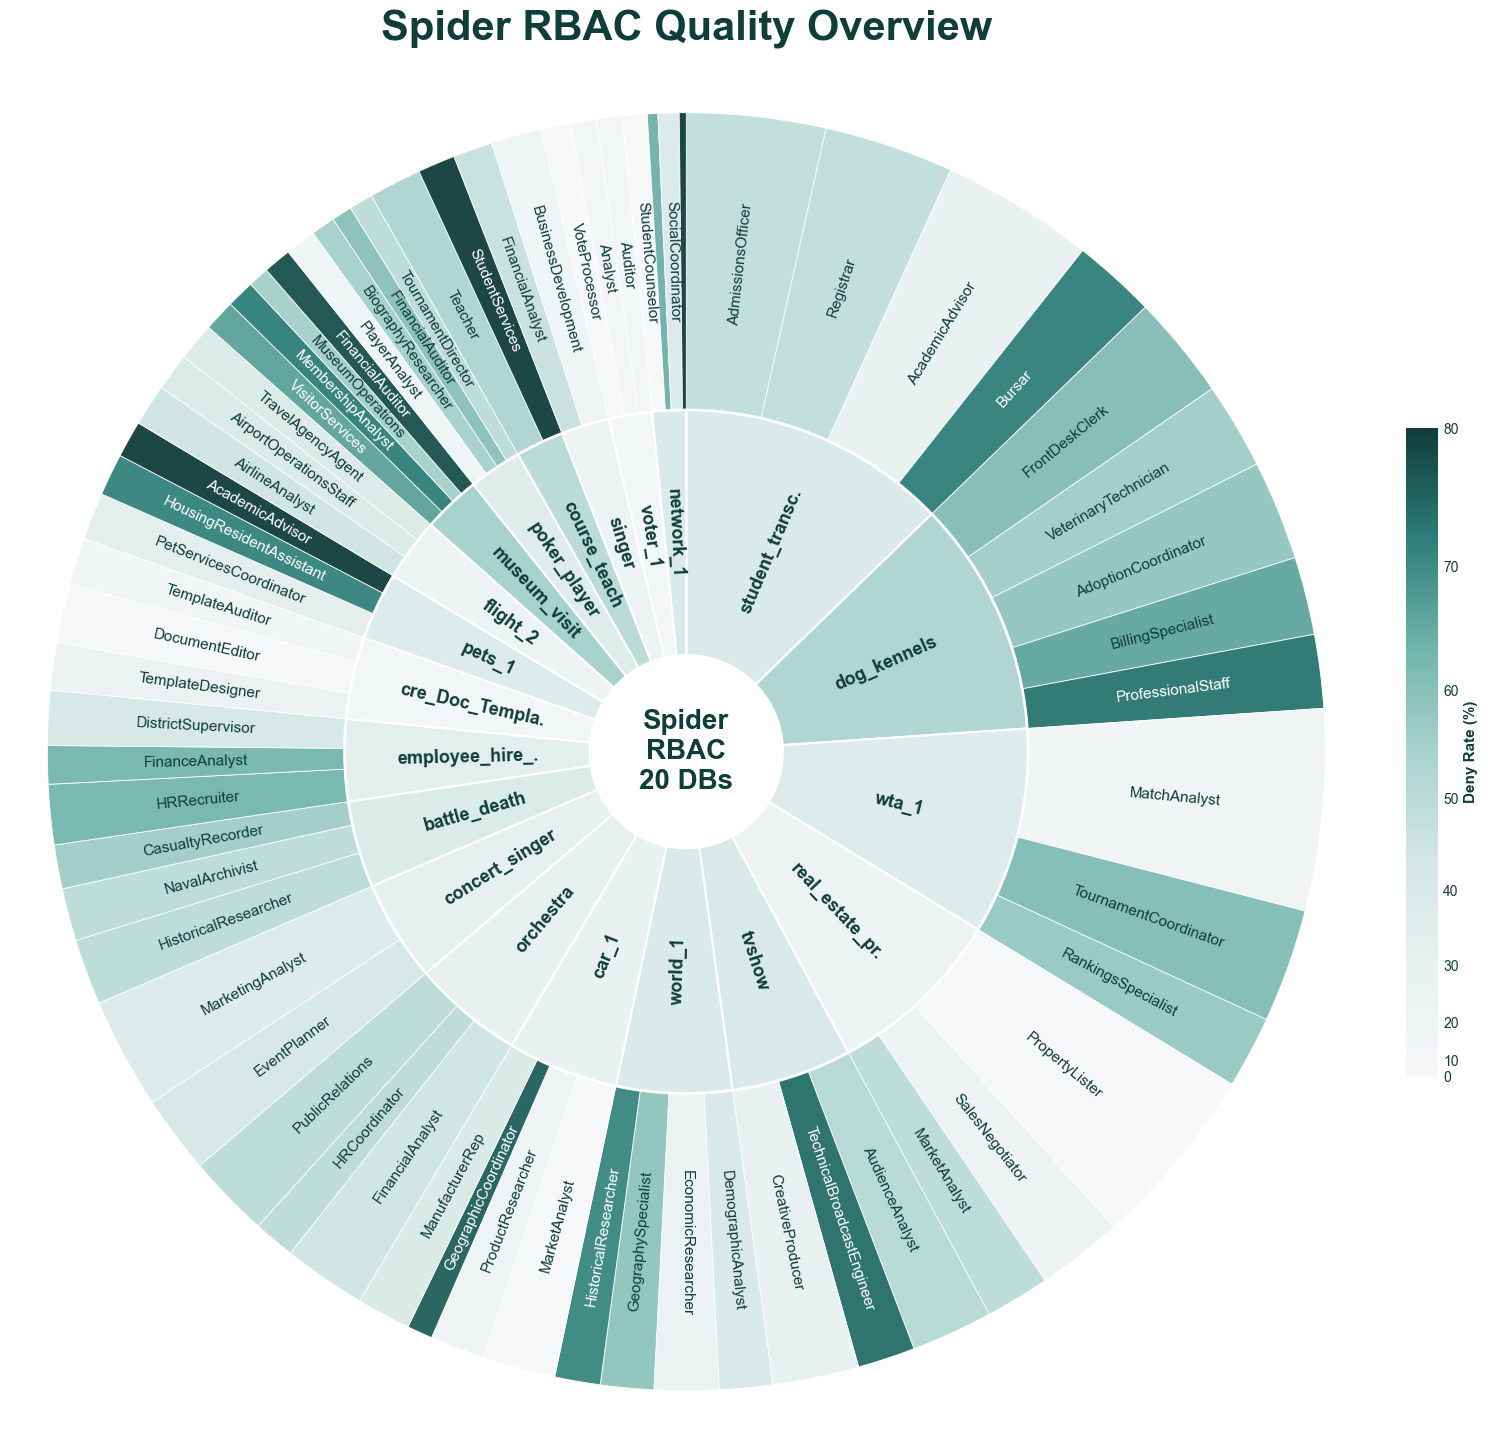

In [92]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
import numpy as np

# ==========================================
# 1. 字体与配色配置 (Configuration)
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

# --- [字体控制中心] ---
FONT_SIZE_TITLE  = 30  # 主标题
FONT_SIZE_CENTER = 20  # 中心数字
FONT_SIZE_DB     = 13  # 内圈 (Database)
FONT_SIZE_ROLE   = 11  # 外圈 (Role)
FONT_SIZE_CBAR   = 11  # 图例
MIN_ANGLE_LABEL  = 2.0 # 只有扇区角度大于此值才显示文字(避免大字重叠)

# --- 配色方案 (Neutral -> Teal) ---
deny_colors = [
    "#F6F7F9",  # very light neutral
    "#E8F1F0",  # light aqua-gray
    "#D3E7E4",  # soft mint
    "#A9D2CC",  # muted teal
    "#6FB3AA",  # teal
    "#2C7C77",  # deep teal
    "#0F3D3A",  # very deep teal (accent)
]
cmap = LinearSegmentedColormap.from_list("deny_rate_teal", deny_colors)
norm = PowerNorm(gamma=1.8, vmin=0, vmax=80)

# 文字颜色
TEXT_DARK = '#0F3D3A' 
TEXT_LIGHT = '#FFFFFF'

# ==========================================
# 2. 布局配置
# ==========================================
CENTER_RADIUS = 0.15
INNER_WIDTH   = 0.38
GAP_WIDTH     = 0.002
OUTER_WIDTH   = 0.46

INNER_R1 = CENTER_RADIUS
INNER_R2 = INNER_R1 + INNER_WIDTH
OUTER_R1 = INNER_R2 + GAP_WIDTH
OUTER_R2 = OUTER_R1 + OUTER_WIDTH

# ==========================================
# 3. 辅助函数
# ==========================================
def get_text_color(bg_color):
    """自动对比色"""
    r, g, b = to_rgb(bg_color)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return TEXT_LIGHT if luminance < 0.55 else TEXT_DARK

def get_smart_rotation(theta1, theta2):
    mid = (theta1 + theta2) / 2
    rot = mid
    norm_ang = mid % 360
    if 90 < norm_ang < 270:
        rot += 180
    return rot

def truncate_text(text, max_len=14):
    if len(text) <= max_len: return text
    return text[:max_len-1] + '.'

# ==========================================
# 4. 绘图主逻辑
# ==========================================
if 'db_data' not in locals():
    print("Warning: db_data missing.")
else:
    # 排序
    db_data.sort(key=lambda x: x['total_cols'], reverse=True)
    total_cols_all = sum(d['total_cols'] for d in db_data) or 1

    fig, ax = plt.subplots(figsize=(15, 15), subplot_kw={'aspect': 'equal'}) # 画布加大到15
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(-1.05, 1.05)
    ax.axis('off')

    current_angle = 90

    for db in db_data:
        angle_span = (db['total_cols'] / total_cols_all) * 360
        if angle_span == 0: continue
        
        theta1, theta2 = current_angle - angle_span, current_angle
        
        # --- 内圈 (Database) ---
        db_rgba = cmap(norm(db['deny_rate']))
        
        wedge = Wedge(center=(0, 0), r=INNER_R2, theta1=theta1, theta2=theta2,
                      width=INNER_WIDTH, facecolor=db_rgba,
                      edgecolor='white', linewidth=1.5)
        ax.add_patch(wedge)
        
        # --- 内圈标签 ---
        if angle_span > MIN_ANGLE_LABEL:
            mid = (theta1 + theta2) / 2
            label_r = INNER_R1 + (INNER_WIDTH * 0.5)
            lx = label_r * np.cos(np.radians(mid))
            ly = label_r * np.sin(np.radians(mid))
            rot = get_smart_rotation(theta1, theta2)
            font_color = get_text_color(db_rgba)
            
            # [UPGRADE] 字体加大
            ax.text(lx, ly, truncate_text(db['db_id'], 15),
                    ha='center', va='center', rotation=rot, rotation_mode='anchor',
                    fontsize=FONT_SIZE_DB, fontweight='bold', color=font_color)

        # --- 外圈 (Roles) ---
        if db['roles']:
            total_access = sum(r['accessible'] for r in db['roles'])
            role_start = theta2 
            
            for role in db['roles']:
                if total_access > 0:
                    r_span = (role['accessible'] / total_access) * angle_span
                else:
                    r_span = angle_span / len(db['roles'])
                
                role_end = role_start - r_span
                role_rgba = cmap(norm(role['deny_rate']))
                r_font_color = get_text_color(role_rgba)
                
                r_wedge = Wedge(center=(0, 0), r=OUTER_R2, theta1=role_end, theta2=role_start,
                                width=OUTER_WIDTH, facecolor=role_rgba,
                                edgecolor='white', linewidth=0.6, alpha=0.95)
                ax.add_patch(r_wedge)
                
                # --- 外圈标签 ---
                # 只有当扇区足够大时才显示，避免文字打架
                if r_span > MIN_ANGLE_LABEL * 0.8: 
                    rmid = (role_start + role_end) / 2
                    r_label_r = OUTER_R1 + (OUTER_WIDTH * 0.5)
                    rx = r_label_r * np.cos(np.radians(rmid))
                    ry = r_label_r * np.sin(np.radians(rmid))
                    r_rot = get_smart_rotation(role_end, role_start)
                    
                    # [UPGRADE] 字体加大
                    ax.text(rx, ry, role['role'],
                            ha='center', va='center', rotation=r_rot, rotation_mode='anchor',
                            fontsize=FONT_SIZE_ROLE, fontweight='medium', color=r_font_color)
                
                role_start = role_end

        current_angle -= angle_span

    # ==========================================
    # 5. 装饰细节 (全部加大)
    # ==========================================
    
    # 中心
    center_text = f"Spider\nRBAC\n{len(db_data)} DBs"
    ax.text(0, 0, center_text, ha='center', va='center', 
            fontsize=FONT_SIZE_CENTER, fontweight='heavy', color=TEXT_DARK)

    # 标题
    ax.set_title('Spider RBAC Quality Overview', 
                 fontsize=FONT_SIZE_TITLE, fontweight='bold', y=1.02, color=TEXT_DARK)

    # Legend
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.03, pad=0.03, shrink=0.45)
    cbar.set_label('Deny Rate (%)', fontsize=FONT_SIZE_CBAR, weight='bold', color=TEXT_DARK)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(colors=TEXT_DARK, labelcolor=TEXT_DARK, labelsize=FONT_SIZE_CBAR-1, length=0)

    plt.tight_layout()
    plt.show()

## 8. Notes

### Workflow
1. Section 3: Generate initial column-level roles
2. Section 4: Validate against database schemas
3. Section 5: Quality assessment (Deny Rate, Similarity, Overlap)
4. Section 6: Human-in-the-loop regeneration
5. Section 7: Preview and export

### Quality Thresholds
| Metric | Range | Description |
|--------|-------|-------------|
| Deny Rate | 5-90% | Columns NOT accessible |
| Semantic Similarity | >0.6 | Description matches policy |
| Policy Overlap | <70% | Role differentiation |

### Outputs
- `outputs/spider_column_level_rbac_assignments_v2.json`
- `outputs/column_level_rbac_dataset_spider_YYYYMMDD.json`